<a href="https://colab.research.google.com/github/ceehrt/LSTM-GRU-SRN-models-for-ticket-classification-2026-Reproduction-/blob/main/LSTM_GRU_SRN_ticket_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
import json
import numpy as np
import pandas as pd
import re, nltk, spacy, string
import en_core_web_sm
nlp = en_core_web_sm.load()

#Importing libraries required for the case study and to plot charts
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from plotly.offline import plot
import plotly.graph_objects as go
import plotly.express as px
%matplotlib inline

#Importing Regular Expressions for String manipulation
import re

# hide warnings
import warnings
warnings.filterwarnings('ignore')

# set options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from pprint import pprint

In [101]:
root_path = '/content/drive/MyDrive/Colab Notebooks/complaints-2021-05-14_08_16.json'

In [102]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Now, the file path should be accessible if it's correct
root_path = '/content/drive/MyDrive/Colab Notebooks/complaints-2021-05-14_08_16.json'

# Open the file
f = open(root_path)

# returns JSON object as a dictionary
data = json.load(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [103]:
df=pd.json_normalize(data)
df.head()

,_index,_type,_id,_score,_source.tags,_source.zip_code,_source.complaint_id,_source.issue,_source.date_received,_source.state,_source.consumer_disputed,_source.product,_source.company_response,_source.company,_source.submitted_via,_source.date_sent_to_company,_source.company_public_response,_source.sub_product,_source.timely,_source.complaint_what_happened,_source.sub_issue,_source.consumer_consent_provided
0,complaint-public-v2,complaint,3211475,0.0,None,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,N/A,Debt collection,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,None,Credit card debt,Yes,,Debt is not yours,Consent not provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,N/A,Debt collection,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Credit card debt,Yes,Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. \nIn 2018 I wrote to Chase asking for debt verification and what they sent me a statement which is not acceptable. I am asking the bank to validate the debt. Instead I been receiving mail every month from them attempting to collect a debt. \nI have a right to know this information as a consumer. \n\nChase account # XXXX XXXX XXXX XXXX Thanks in advance for your help.,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,N/A,Credit card or prepaid card,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anniversary date would not change. It turned the agent was giving me the wrong information in order to upgrade the account. XXXX changed my anniversary date from XX/XX/XXXX to XX/XX/XXXX without my consent! XXXX has the recording of the agent who was misled me.,Problem with rewards from credit card,Consent provided
3,complaint-public-v2,complaint,2673060,0.0,None,48066,2673060,Trouble during payment process,2017-09-13T12:00:00-05:00,MI,N/A,Mortgage,Closed with explanation,JPMORGAN CHASE & CO.,Web,2017-09-14T12:00:00-05:00,None,Conventional home mortgage,Yes,,None,Consent not provided
4,complaint-public-v2,complaint,3203545,0.0,None,10473,3203545,Fees or interest,2019-04-05T12:00:00-05:00,NY,N/A,Credit card or prepaid card,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2019-04-05T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,,Charged too much interest,N/A


In [104]:
num_rows, num_columns = df.shape

print(f"Rows: {num_rows}, Columns: {num_columns}")

Rows: 78313, Columns: 22


In [105]:
print(df.columns.tolist())

['_index', '_type', '_id', '_score', '_source.tags', '_source.zip_code', '_source.complaint_id', '_source.issue', '_source.date_received', '_source.state', '_source.consumer_disputed', '_source.product', '_source.company_response', '_source.company', '_source.submitted_via', '_source.date_sent_to_company', '_source.company_public_response', '_source.sub_product', '_source.timely', '_source.complaint_what_happened', '_source.sub_issue', '_source.consumer_consent_provided']


In [106]:
print(df.columns)

Index(['_index', '_type', '_id', '_score', '_source.tags', '_source.zip_code',
       '_source.complaint_id', '_source.issue', '_source.date_received',
       '_source.state', '_source.consumer_disputed', '_source.product',
       '_source.company_response', '_source.company', '_source.submitted_via',
       '_source.date_sent_to_company', '_source.company_public_response',
       '_source.sub_product', '_source.timely',
       '_source.complaint_what_happened', '_source.sub_issue',
       '_source.consumer_consent_provided'],
      dtype='object')


In [107]:
df = df[['_source.complaint_what_happened','_source.product','_source.sub_product','_source.issue','_source.sub_issue',]]
df.head()

,_source.complaint_what_happened,_source.product,_source.sub_product,_source.issue,_source.sub_issue
0,,Debt collection,Credit card debt,Attempts to collect debt not owed,Debt is not yours
1,Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. \nIn 2018 I wrote to Chase asking for debt verification and what they sent me a statement which is not acceptable. I am asking the bank to validate the debt. Instead I been receiving mail every month from them attempting to collect a debt. \nI have a right to know this information as a consumer. \n\nChase account # XXXX XXXX XXXX XXXX Thanks in advance for your help.,Debt collection,Credit card debt,Written notification about debt,Didn't receive enough information to verify debt
2,I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anniversary date would not change. It turned the agent was giving me the wrong information in order to upgrade the account. XXXX changed my anniversary date from XX/XX/XXXX to XX/XX/XXXX without my consent! XXXX has the recording of the agent who was misled me.,Credit card or prepaid card,General-purpose credit card or charge card,"Other features, terms, or problems",Problem with rewards from credit card
3,,Mortgage,Conventional home mortgage,Trouble during payment process,None
4,,Credit card or prepaid card,General-purpose credit card or charge card,Fees or interest,Charged too much interest


In [108]:
df = df.rename(columns={'_source.complaint_what_happened': 'complaint_text', '_source.product': 'category','_source.sub_product': 'sub_category'})
df.head()

,complaint_text,category,sub_category,_source.issue,_source.sub_issue
0,,Debt collection,Credit card debt,Attempts to collect debt not owed,Debt is not yours
1,Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. \nIn 2018 I wrote to Chase asking for debt verification and what they sent me a statement which is not acceptable. I am asking the bank to validate the debt. Instead I been receiving mail every month from them attempting to collect a debt. \nI have a right to know this information as a consumer. \n\nChase account # XXXX XXXX XXXX XXXX Thanks in advance for your help.,Debt collection,Credit card debt,Written notification about debt,Didn't receive enough information to verify debt
2,I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anniversary date would not change. It turned the agent was giving me the wrong information in order to upgrade the account. XXXX changed my anniversary date from XX/XX/XXXX to XX/XX/XXXX without my consent! XXXX has the recording of the agent who was misled me.,Credit card or prepaid card,General-purpose credit card or charge card,"Other features, terms, or problems",Problem with rewards from credit card
3,,Mortgage,Conventional home mortgage,Trouble during payment process,None
4,,Credit card or prepaid card,General-purpose credit card or charge card,Fees or interest,Charged too much interest


In [109]:
df['category'] = df['category'] + '+' + df['sub_category']
df = df.drop(['sub_category'],axis= 1)
df.head()

,complaint_text,category,_source.issue,_source.sub_issue
0,,Debt collection+Credit card debt,Attempts to collect debt not owed,Debt is not yours
1,Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. \nIn 2018 I wrote to Chase asking for debt verification and what they sent me a statement which is not acceptable. I am asking the bank to validate the debt. Instead I been receiving mail every month from them attempting to collect a debt. \nI have a right to know this information as a consumer. \n\nChase account # XXXX XXXX XXXX XXXX Thanks in advance for your help.,Debt collection+Credit card debt,Written notification about debt,Didn't receive enough information to verify debt
2,I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anniversary date would not change. It turned the agent was giving me the wrong information in order to upgrade the account. XXXX changed my anniversary date from XX/XX/XXXX to XX/XX/XXXX without my consent! XXXX has the recording of the agent who was misled me.,Credit card or prepaid card+General-purpose credit card or charge card,"Other features, terms, or problems",Problem with rewards from credit card
3,,Mortgage+Conventional home mortgage,Trouble during payment process,None
4,,Credit card or prepaid card+General-purpose credit card or charge card,Fees or interest,Charged too much interest


In [110]:
df.complaint_text.isnull().sum()

np.int64(0)

In [111]:
len(df[df['complaint_text']==''])

57241

In [112]:
df[df['complaint_text']==''] = np.nan
df.complaint_text.isnull().sum()

np.int64(57241)

In [113]:
#Remove all rows where complaints column is nan
# Lets drop all the rows where complaint_text is null
df = df[~df['complaint_text'].isnull()]
df.complaint_text.isnull().sum()

np.int64(0)

In [114]:
df.head()

,complaint_text,category,_source.issue,_source.sub_issue
1,Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. \nIn 2018 I wrote to Chase asking for debt verification and what they sent me a statement which is not acceptable. I am asking the bank to validate the debt. Instead I been receiving mail every month from them attempting to collect a debt. \nI have a right to know this information as a consumer. \n\nChase account # XXXX XXXX XXXX XXXX Thanks in advance for your help.,Debt collection+Credit card debt,Written notification about debt,Didn't receive enough information to verify debt
2,I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anniversary date would not change. It turned the agent was giving me the wrong information in order to upgrade the account. XXXX changed my anniversary date from XX/XX/XXXX to XX/XX/XXXX without my consent! XXXX has the recording of the agent who was misled me.,Credit card or prepaid card+General-purpose credit card or charge card,"Other features, terms, or problems",Problem with rewards from credit card
10,"Chase Card was reported on XX/XX/2019. However, fraudulent application have been submitted my identity without my consent to fraudulently obtain services. Do not extend credit without verifying the identity of the applicant.","Credit reporting, credit repair services, or other personal consumer reports+Other personal consumer report",Incorrect information on your report,Information belongs to someone else
11,"On XX/XX/2018, while trying to book a XXXX XXXX ticket, I came across an offer for {$300.00} to be applied towards the ticket if I applied for a rewards card. I put in my information for the offer and within less than a minute, was notified via the screen that a decision could not be made. I immediately contacted XXXX and was referred to Chase Bank. I then immediately contacted Chase bank within no more than 10minutes of getting the notification on the screen and I was told by the Chase representative I spoke with that my application was denied but she could not state why. I asked for more information about the XXXX offer and she explained that even if I had been approved, the credit offer only gets applied after the first account statement and could not be used to purchase the ticket. I then explicitly told her I was glad I got denied and I was ABSOLUTELY no longer interested in the account. I asked that the application be withdrawn and the representative obliged. This all happened no later than 10mins after putting in the application on XX/XX/2018. Notwithstanding my explicit request not to proceed with the application and contrary to what I was told by the Chase representative, Chase did in fact go ahead to open a credit account in my name on XX/XX/2018. This is now being reported in my Credit Report and Chase has refused to correct this information on my credit report even though they went ahead to process an application which I did not consent to and out of their error.","Credit reporting, credit repair services, or other personal consumer reports+Credit reporting",Incorrect information on your report,Information belongs to someone else
14,my grand son give me check for {$1600.00} i deposit it into my chase account after fund clear my chase bank closed my account never paid me my money they said they need to speek with my grand son check was clear money was taking by my chase bank refuse to pay me my money my grand son called chase 2 times they told him i should call not him to verify the check owner he is out the country most the time date happen XX/XX/2018 check number XXXX claim number is XXXX with chase,Checking or savings account+Checking account,Managing an account,Funds not handled or disbursed as instructed


In [115]:
df["_source.issue"].isnull().sum()

np.int64(0)

In [116]:
df["_source.sub_issue"].isnull().sum()

np.int64(8176)

In [117]:
#df['complaint_text'] = df['_source.issue'] + '+' + df['_source.sub_issue'] + '+' + df['complaint_text']
#df = df.drop(['sub_category'],axis= 1)
df['issue'] = df['_source.issue']
df['sub_issue'] = df['_source.sub_issue']
df['complaint_text'] = df['issue'] + ' + ' + df['sub_issue'] + ' + ' + df['complaint_text']

df.head()

,complaint_text,category,_source.issue,_source.sub_issue,issue,sub_issue
1,Written notification about debt + Didn't receive enough information to verify debt + Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. \nIn 2018 I wrote to Chase asking for debt verification and what they sent me a statement which is not acceptable. I am asking the bank to validate the debt. Instead I been receiving mail every month from them attempting to collect a debt. \nI have a right to know this information as a consumer. \n\nChase account # XXXX XXXX XXXX XXXX Thanks in advance for your help.,Debt collection+Credit card debt,Written notification about debt,Didn't receive enough information to verify debt,Written notification about debt,Didn't receive enough information to verify debt
2,"Other features, terms, or problems + Problem with rewards from credit card + I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anniversary date would not change. It turned the agent was giving me the wrong information in order to upgrade the account. XXXX changed my anniversary date from XX/XX/XXXX to XX/XX/XXXX without my consent! XXXX has the recording of the agent who was misled me.",Credit card or prepaid card+General-purpose credit card or charge card,"Other features, terms, or problems",Problem with rewards from credit card,"Other features, terms, or problems",Problem with rewards from credit card
10,"Incorrect information on your report + Information belongs to someone else + Chase Card was reported on XX/XX/2019. However, fraudulent application have been submitted my identity without my consent to fraudulently obtain services. Do not extend credit without verifying the identity of the applicant.","Credit reporting, credit repair services, or other personal consumer reports+Other personal consumer report",Incorrect information on your report,Information belongs to someone else,Incorrect information on your report,Information belongs to someone else
11,"Incorrect information on your report + Information belongs to someone else + On XX/XX/2018, while trying to book a XXXX XXXX ticket, I came across an offer for {$300.00} to be applied towards the ticket if I applied for a rewards card. I put in my information for the offer and within less than a minute, was notified via the screen that a decision could not be made. I immediately contacted XXXX and was referred to Chase Bank. I then immediately contacted Chase bank within no more than 10minutes of getting the notification on the screen and I was told by the Chase representative I spoke with that my application was denied but she could not state why. I asked for more information about the XXXX offer and she explained that even if I had been approved, the credit offer only gets applied after the first account statement and could not be used to purchase the ticket. I then explicitly told her I was glad I got denied and I was ABSOLUTELY no longer interested in the account. I asked that the application be withdrawn and the representative obliged. This all happened no later than 10mins after putting in the application on XX/XX/2018. Notwithstanding my explicit request not to proceed with the application and contrary to what I was told by the Chase representative, Chase did in fact go ahead to open a credit account in my name on XX/XX/2018. This is now being reported in my Credit Report and Chase has refused to correct this information on my credit report even though they went ahead to process an application which I did not consent to and out of their error.","Credit reporting, credit repair services, or other personal consumer reports+Credit reporting",Incorrect information on your report,Information belongs to someone else,Incorrect information on your report,Information belongs to someone else
14,Managing an account + Funds not handled or disbursed as instructed + my grand son give me check for {$1600.0

In [118]:
df = df.drop(['_source.issue'],axis= 1)
df = df.drop(['_source.sub_issue'],axis= 1)

In [119]:
print(df.columns)

Index(['complaint_text', 'category', 'issue', 'sub_issue'], dtype='object')


In [120]:
df.head()

,complaint_text,category,issue,sub_issue
1,Written notification about debt + Didn't receive enough information to verify debt + Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. \nIn 2018 I wrote to Chase asking for debt verification and what they sent me a statement which is not acceptable. I am asking the bank to validate the debt. Instead I been receiving mail every month from them attempting to collect a debt. \nI have a right to know this information as a consumer. \n\nChase account # XXXX XXXX XXXX XXXX Thanks in advance for your help.,Debt collection+Credit card debt,Written notification about debt,Didn't receive enough information to verify debt
2,"Other features, terms, or problems + Problem with rewards from credit card + I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anniversary date would not change. It turned the agent was giving me the wrong information in order to upgrade the account. XXXX changed my anniversary date from XX/XX/XXXX to XX/XX/XXXX without my consent! XXXX has the recording of the agent who was misled me.",Credit card or prepaid card+General-purpose credit card or charge card,"Other features, terms, or problems",Problem with rewards from credit card
10,"Incorrect information on your report + Information belongs to someone else + Chase Card was reported on XX/XX/2019. However, fraudulent application have been submitted my identity without my consent to fraudulently obtain services. Do not extend credit without verifying the identity of the applicant.","Credit reporting, credit repair services, or other personal consumer reports+Other personal consumer report",Incorrect information on your report,Information belongs to someone else
11,"Incorrect information on your report + Information belongs to someone else + On XX/XX/2018, while trying to book a XXXX XXXX ticket, I came across an offer for {$300.00} to be applied towards the ticket if I applied for a rewards card. I put in my information for the offer and within less than a minute, was notified via the screen that a decision could not be made. I immediately contacted XXXX and was referred to Chase Bank. I then immediately contacted Chase bank within no more than 10minutes of getting the notification on the screen and I was told by the Chase representative I spoke with that my application was denied but she could not state why. I asked for more information about the XXXX offer and she explained that even if I had been approved, the credit offer only gets applied after the first account statement and could not be used to purchase the ticket. I then explicitly told her I was glad I got denied and I was ABSOLUTELY no longer interested in the account. I asked that the application be withdrawn and the representative obliged. This all happened no later than 10mins after putting in the application on XX/XX/2018. Notwithstanding my explicit request not to proceed with the application and contrary to what I was told by the Chase representative, Chase did in fact go ahead to open a credit account in my name on XX/XX/2018. This is now being reported in my Credit Report and Chase has refused to correct this information on my credit report even though they went ahead to process an application which I did not consent to and out of their error.","Credit reporting, credit repair services, or other personal consumer reports+Credit reporting",Incorrect information on your report,Information belongs to someone else
14,Managing an account + Funds not handled or disbursed as instructed + my grand son give me check for {$1600.00} i deposit it into my chase account after fund clear my chase bank closed my account never paid me my money they said they need to speek with my grand son check was clear money was taking by my chase bank refuse to pay me my money my grand son called chase 2 times they told him i should call not him to verify the check owner he is

In [121]:
len(df[df['complaint_text']==''])

0

In [122]:
df["issue"].isnull().sum()

np.int64(0)

In [123]:
df["sub_issue"].isnull().sum()

np.int64(8176)

In [124]:
df = df[~df['sub_issue'].isnull()]

In [125]:
num_records = df.shape[0]
print(f"Number of records: {num_records}")

Number of records: 12896


In [126]:


# Write your function here to clean the text and remove all the unnecessary elements.
# Preparing text for Topic modelling
def clean_text(text):
    text = text.lower()  # Make the text lowercase
    text = re.sub('\[.*\]','', text).strip() # Remove text in square brackets
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = re.sub('\S*\d\S*\s*','', text).strip()  # Remove words containing numbers
    return text.strip()

In [127]:
df.complaint_text = df.complaint_text.apply(lambda x: clean_text(x))
df.complaint_text.head()

,complaint_text
1,written notification about debt didnt receive enough information to verify debt good morning my name is xxxx xxxx and i appreciate it if you could help me put a stop to chase bank cardmember services \nin i wrote to chase asking for debt verification and what they sent me a statement which is not acceptable i am asking the bank to validate the debt instead i been receiving mail every month from them attempting to collect a debt \ni have a right to know this information as a consumer \n\nchase account xxxx xxxx xxxx xxxx thanks in advance for your help
2,other features terms or problems problem with rewards from credit card i upgraded my xxxx xxxx card in and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account xxxx changed my anniversary date from xxxxxxxx to xxxxxxxx without my consent xxxx has the recording of the agent who was misled me
10,incorrect information on your report information belongs to someone else chase card was reported on however fraudulent application have been submitted my identity without my consent to fraudulently obtain services do not extend credit without verifying the identity of the applicant
11,incorrect information on your report information belongs to someone else on while trying to book a xxxx xxxx ticket i came across an offer for to be applied towards the ticket if i applied for a rewards card i put in my information for the offer and within less than a minute was notified via the screen that a decision could not be made i immediately contacted xxxx and was referred to chase bank i then immediately contacted chase bank within no more than of getting the notification on the screen and i was told by the chase representative i spoke with that my application was denied but she could not state why i asked for more information about the xxxx offer and she explained that even if i had been approved the credit offer only gets applied after the first account statement and could not be used to purchase the ticket i then explicitly told her i was glad i got denied and i was absolutely no longer interested in the account i asked that the application be withdrawn and the representative obliged this all happened no later than after putting in the application on notwithstanding my explicit request not to proceed with the application and contrary to what i was told by the chase representative chase did in fact go ahead to open a credit account in my name on this is now being reported in my credit report and chase has refused to correct this information on my credit report even though they went ahead to process an application which i did not consent to and out of their error
14,managing an account funds not handled or disbursed as instructed my grand son give me check for i deposit it into my chase account after fund clear my chase bank closed my account never paid me my money they said they need to speek with my grand son check was clear money was taking by my chase bank refuse to pay me my money my grand son called chase times they told him i should call not him to verify the check owner he is out the country most the time date happen check number xxxx claim number is xxxx with chase


In [128]:
#Write your function to Lemmatize the texts
# lemmatization
#Function to Lemmatize the texts
stopwords = nlp.Defaults.stop_words
def lemmatizer(text):
    doc = nlp(text)
    sent = [token.lemma_ for token in doc if not token.text in set(stopwords)]
    return ' '.join(sent)

In [129]:
# Lemmatize the complaints
df['lemma'] =  df.complaint_text.apply(lambda x: lemmatizer(x))
df.head()

,complaint_text,category,issue,sub_issue,lemma
1,written notification about debt didnt receive enough information to verify debt good morning my name is xxxx xxxx and i appreciate it if you could help me put a stop to chase bank cardmember services \nin i wrote to chase asking for debt verification and what they sent me a statement which is not acceptable i am asking the bank to validate the debt instead i been receiving mail every month from them attempting to collect a debt \ni have a right to know this information as a consumer \n\nchase account xxxx xxxx xxxx xxxx thanks in advance for your help,Debt collection+Credit card debt,Written notification about debt,Didn't receive enough information to verify debt,write notification debt not receive information verify debt good morning xxxx xxxx appreciate help stop chase bank cardmember service \n write chase ask debt verification send statement acceptable ask bank validate debt instead receive mail month attempt collect debt \n right know information consumer \n\n chase account xxxx xxxx xxxx xxxx thank advance help
2,other features terms or problems problem with rewards from credit card i upgraded my xxxx xxxx card in and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account xxxx changed my anniversary date from xxxxxxxx to xxxxxxxx without my consent xxxx has the recording of the agent who was misled me,Credit card or prepaid card+General-purpose credit card or charge card,"Other features, terms, or problems",Problem with rewards from credit card,feature term problem problem reward credit card upgrade xxxx xxxx card tell agent upgrade anniversary date change turn agent give wrong information order upgrade account xxxx change anniversary date xxxxxxxx xxxxxxxx consent xxxx recording agent mislead
10,incorrect information on your report information belongs to someone else chase card was reported on however fraudulent application have been submitted my identity without my consent to fraudulently obtain services do not extend credit without verifying the identity of the applicant,"Credit reporting, credit repair services, or other personal consumer reports+Other personal consumer report",Incorrect information on your report,Information belongs to someone else,incorrect information report information belong chase card report fraudulent application submit identity consent fraudulently obtain service extend credit verify identity applicant
11,incorrect information on your report information belongs to someone else on while trying to book a xxxx xxxx ticket i came across an offer for to be applied towards the ticket if i applied for a rewards card i put in my information for the offer and within less than a minute was notified via the screen that a decision could not be made i immediately contacted xxxx and was referred to chase bank i then immediately contacted chase bank within no more than of getting the notification on the screen and i was told by the chase representative i spoke with that my application was denied but she could not state why i asked for more information about the xxxx offer and she explained that even if i had been approved the credit offer only gets applied after the first account statement and could not be used to purchase the ticket i then explicitly told her i was glad i got denied and i was absolutely no longer interested in the account i asked that the application be withdrawn and the representative obliged this all happened no later than after putting in the application on notwithstanding my explicit request not to proceed with the application and contrary to what i was told by the chase representative chase did in fact go ahead to open a credit account in my name on this is now being reported in my credit report and chase has refused to correct this information on my credit report even though they went ahead to process an application which i d

In [130]:
#Create a dataframe('df_clean') that will have only the complaints and the lemmatized complaints
df_clean = df[['complaint_text','lemma','category']]
df_clean.head()

,complaint_text,lemma,category
1,written notification about debt didnt receive enough information to verify debt good morning my name is xxxx xxxx and i appreciate it if you could help me put a stop to chase bank cardmember services \nin i wrote to chase asking for debt verification and what they sent me a statement which is not acceptable i am asking the bank to validate the debt instead i been receiving mail every month from them attempting to collect a debt \ni have a right to know this information as a consumer \n\nchase account xxxx xxxx xxxx xxxx thanks in advance for your help,write notification debt not receive information verify debt good morning xxxx xxxx appreciate help stop chase bank cardmember service \n write chase ask debt verification send statement acceptable ask bank validate debt instead receive mail month attempt collect debt \n right know information consumer \n\n chase account xxxx xxxx xxxx xxxx thank advance help,Debt collection+Credit card debt
2,other features terms or problems problem with rewards from credit card i upgraded my xxxx xxxx card in and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account xxxx changed my anniversary date from xxxxxxxx to xxxxxxxx without my consent xxxx has the recording of the agent who was misled me,feature term problem problem reward credit card upgrade xxxx xxxx card tell agent upgrade anniversary date change turn agent give wrong information order upgrade account xxxx change anniversary date xxxxxxxx xxxxxxxx consent xxxx recording agent mislead,Credit card or prepaid card+General-purpose credit card or charge card
10,incorrect information on your report information belongs to someone else chase card was reported on however fraudulent application have been submitted my identity without my consent to fraudulently obtain services do not extend credit without verifying the identity of the applicant,incorrect information report information belong chase card report fraudulent application submit identity consent fraudulently obtain service extend credit verify identity applicant,"Credit reporting, credit repair services, or other personal consumer reports+Other personal consumer report"
11,incorrect information on your report information belongs to someone else on while trying to book a xxxx xxxx ticket i came across an offer for to be applied towards the ticket if i applied for a rewards card i put in my information for the offer and within less than a minute was notified via the screen that a decision could not be made i immediately contacted xxxx and was referred to chase bank i then immediately contacted chase bank within no more than of getting the notification on the screen and i was told by the chase representative i spoke with that my application was denied but she could not state why i asked for more information about the xxxx offer and she explained that even if i had been approved the credit offer only gets applied after the first account statement and could not be used to purchase the ticket i then explicitly told her i was glad i got denied and i was absolutely no longer interested in the account i asked that the application be withdrawn and the representative obliged this all happened no later than after putting in the application on notwithstanding my explicit request not to proceed with the application and contrary to what i was told by the chase representative chase did in fact go ahead to open a credit account in my name on this is now being reported in my credit report and chase has refused to correct this information on my credit report even though they went ahead to process an application which i did not consent to and out of their error,incorrect information report information belong try book xxxx xxxx ticket come offer apply ticket apply reward card information offer minute notify screen decision immediately contact xxxx refer chase ban

In [131]:
#Write your function to extract the POS tags NN
def extract_pos_tags(text):
    doc = nlp(text)
    sent = [token.text for token in doc if token.tag_ == 'NN']
    return ' '.join(sent)


In [132]:
#The clean dataframe should now contain the raw complaint, lemmatized complaint and the complaint after removing POS tags.
df_clean['complaint_POS_removed'] =  df_clean.lemma.apply(lambda x: extract_pos_tags(x))
df_clean.head()

,complaint_text,lemma,category,complaint_POS_removed
1,written notification about debt didnt receive enough information to verify debt good morning my name is xxxx xxxx and i appreciate it if you could help me put a stop to chase bank cardmember services \nin i wrote to chase asking for debt verification and what they sent me a statement which is not acceptable i am asking the bank to validate the debt instead i been receiving mail every month from them attempting to collect a debt \ni have a right to know this information as a consumer \n\nchase account xxxx xxxx xxxx xxxx thanks in advance for your help,write notification debt not receive information verify debt good morning xxxx xxxx appreciate help stop chase bank cardmember service \n write chase ask debt verification send statement acceptable ask bank validate debt instead receive mail month attempt collect debt \n right know information consumer \n\n chase account xxxx xxxx xxxx xxxx thank advance help,Debt collection+Credit card debt,notification debt information debt morning help chase debt verification statement validate debt mail month attempt debt information consumer chase account advance help
2,other features terms or problems problem with rewards from credit card i upgraded my xxxx xxxx card in and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account xxxx changed my anniversary date from xxxxxxxx to xxxxxxxx without my consent xxxx has the recording of the agent who was misled me,feature term problem problem reward credit card upgrade xxxx xxxx card tell agent upgrade anniversary date change turn agent give wrong information order upgrade account xxxx change anniversary date xxxxxxxx xxxxxxxx consent xxxx recording agent mislead,Credit card or prepaid card+General-purpose credit card or charge card,feature term problem problem reward credit card agent anniversary date change agent information order account change anniversary date agent mislead
10,incorrect information on your report information belongs to someone else chase card was reported on however fraudulent application have been submitted my identity without my consent to fraudulently obtain services do not extend credit without verifying the identity of the applicant,incorrect information report information belong chase card report fraudulent application submit identity consent fraudulently obtain service extend credit verify identity applicant,"Credit reporting, credit repair services, or other personal consumer reports+Other personal consumer report",information report information chase card report application identity consent service extend credit verify identity applicant
11,incorrect information on your report information belongs to someone else on while trying to book a xxxx xxxx ticket i came across an offer for to be applied towards the ticket if i applied for a rewards card i put in my information for the offer and within less than a minute was notified via the screen that a decision could not be made i immediately contacted xxxx and was referred to chase bank i then immediately contacted chase bank within no more than of getting the notification on the screen and i was told by the chase representative i spoke with that my application was denied but she could not state why i asked for more information about the xxxx offer and she explained that even if i had been approved the credit offer only gets applied after the first account statement and could not be used to purchase the ticket i then explicitly told her i was glad i got denied and i was absolutely no longer interested in the account i asked that the application be withdrawn and the representative obliged this all happened no later than after putting in the application on notwithstanding my explicit request not to proceed with the application and contrary to what i was told by the chase representative chase did in fact go ahead 

(array([5.641e+03, 4.020e+03, 1.686e+03, 7.000e+02, 3.650e+02, 1.690e+02,
        1.000e+02, 5.600e+01, 4.600e+01, 2.600e+01, 2.500e+01, 1.200e+01,
        9.000e+00, 1.300e+01, 2.000e+00, 5.000e+00, 3.000e+00, 1.000e+00,
        2.000e+00, 2.000e+00, 4.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 2.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([   23.  ,   271.54,   520.08,   768.62,  1017.16,  1265.7 ,
         1514.24,  1762.78,  2011.32,  2259.86,  2508.4 ,  2756.94,
         3005.48,  3254.02,  3502.56,  3751.1 ,  3999.64,  4248.18,
         4496.72,  4745.26,  4993.8 ,  5242.34,  5490.88,  5739.42,
         5987.96,  6236.5 ,  6485.04,  6733.58,  6982.12,  7230.66,
         7479.2 ,  7727.74,  7976.28

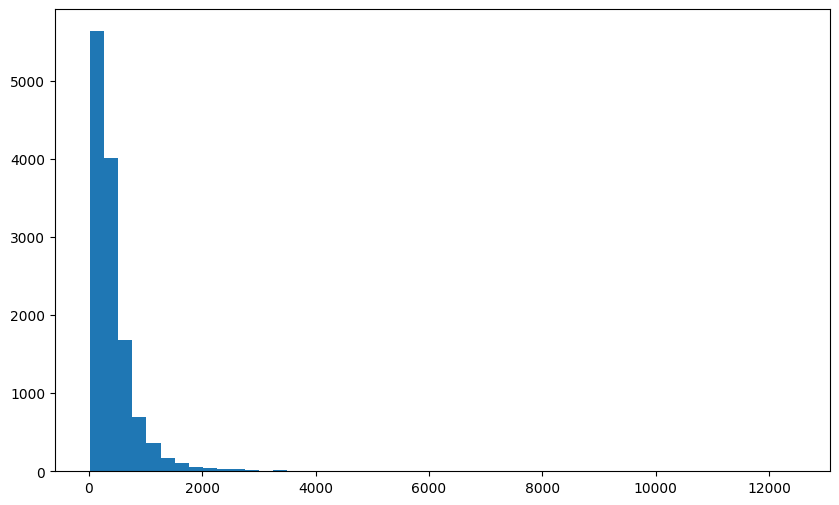

In [133]:
# Write your code here to visualise the data according to the 'Complaint' character length

plt.figure(figsize=(10,6))
doc_lens = [len(d) for d in df_clean.complaint_POS_removed]
plt.hist(doc_lens, bins = 50)

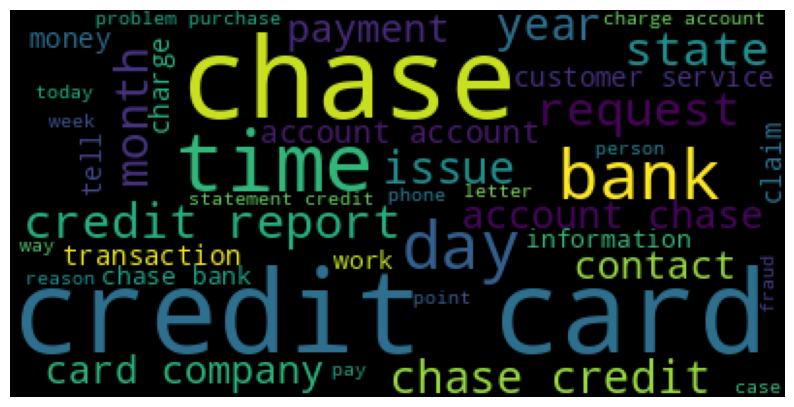

In [134]:
#Using a word cloud find the top 40 words by frequency among all the articles after processing the text

from wordcloud import WordCloud

wordcloud = WordCloud(stopwords=stopwords,max_words=40).generate(str(df_clean.complaint_POS_removed))

print(wordcloud)
plt.figure(figsize=(10,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [135]:
#Removing -PRON- from the text corpus
df_clean['Complaint_clean'] = df_clean['complaint_POS_removed'].str.replace('-PRON-', '')
df_clean = df_clean.drop(['complaint_POS_removed'],axis = 1)

In [136]:
# Write your code here to find the top 30 unigram,bigram,trigram frequency
# among the complaints in the cleaned datafram(df_clean).

def get_top_n_bigram(text, ngram=1, top=None):
    vec = CountVectorizer(ngram_range=(ngram, ngram), stop_words='english').fit(text)
    bag_of_words = vec.transform(text)

    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]

    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top]

In [137]:
top_30_unigrams = get_top_n_bigram(df_clean.Complaint_clean,ngram=1, top=30)
top_30_bigrams = get_top_n_bigram(df_clean.Complaint_clean,ngram=2, top=30)
top_30_trigrams = get_top_n_bigram(df_clean.Complaint_clean,ngram=3, top=30)

In [138]:
#Print the top 10 words in the unigram frequency
print('Top 10 unigrams:\n')
top_30_unigrams[:10]

Top 10 unigrams:



[('account', np.int64(36348)),
 ('chase', np.int64(35561)),
 ('credit', np.int64(27301)),
 ('card', np.int64(26749)),
 ('charge', np.int64(12874)),
 ('payment', np.int64(11071)),
 ('report', np.int64(10398)),
 ('time', np.int64(9203)),
 ('problem', np.int64(9179)),
 ('information', np.int64(8369))]

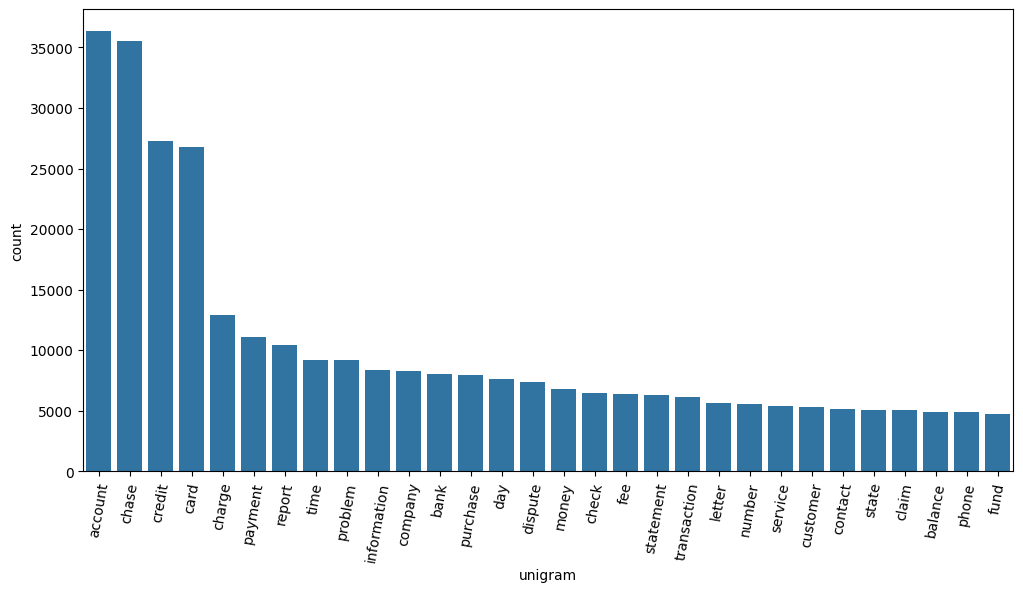

In [139]:
#Plot graph for the top 30 words in the unigram frequency
df1 = pd.DataFrame(top_30_unigrams, columns = ['unigram' , 'count'])
plt.figure(figsize=(12,6))
fig = sns.barplot(x=df1['unigram'], y=df1['count'])
plt.xticks(rotation = 80)
plt.show()

In [140]:
#Print the top 10 words in the bigram frequency
print('Top 10 bigrams:\n')
top_30_bigrams[:10]

Top 10 bigrams:



[('credit card', np.int64(11482)),
 ('purchase statement', np.int64(3092)),
 ('credit report', np.int64(2993)),
 ('account chase', np.int64(2442)),
 ('chase credit', np.int64(2385)),
 ('card company', np.int64(2272)),
 ('customer service', np.int64(2122)),
 ('account account', np.int64(2009)),
 ('chase bank', np.int64(1858)),
 ('problem purchase', np.int64(1842))]

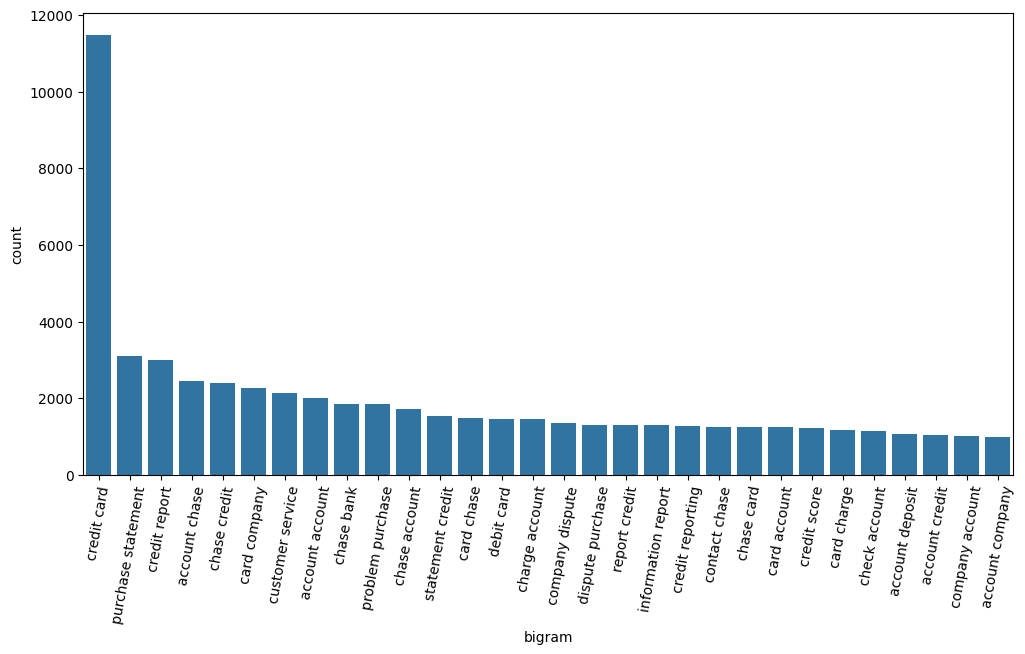

In [141]:
#Plot graph for the top 30 words in the bigram frequency
df2 = pd.DataFrame(top_30_bigrams, columns = ['bigram' , 'count'])
plt.figure(figsize=(12,6))
fig = sns.barplot(x=df2['bigram'], y=df2['count'])
plt.xticks(rotation = 80)
plt.show()

In [142]:
#Print the top 10 words in the trigram frequency
print('Top 10 trigrams:\n')
top_30_trigrams[:10]

Top 10 trigrams:



[('credit card company', np.int64(2167)),
 ('problem purchase statement', np.int64(1808)),
 ('chase credit card', np.int64(1769)),
 ('statement credit card', np.int64(1335)),
 ('purchase statement credit', np.int64(1310)),
 ('card company dispute', np.int64(1309)),
 ('company dispute purchase', np.int64(1274)),
 ('dispute purchase statement', np.int64(1261)),
 ('account company account', np.int64(900)),
 ('credit card account', np.int64(797))]

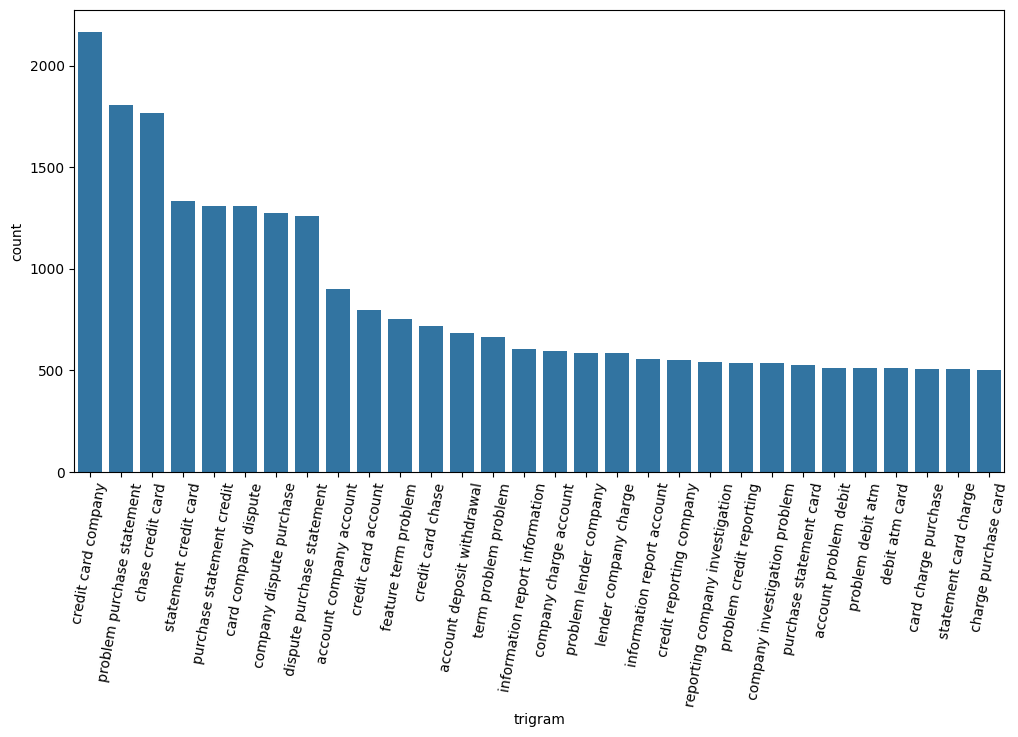

In [143]:
#Plot graph for the top 30 words in the trigram frequency
df3 = pd.DataFrame(top_30_trigrams, columns = ['trigram' , 'count'])
plt.figure(figsize=(12,6))
fig = sns.barplot(x=df3['trigram'], y=df3['count'])
plt.xticks(rotation = 80)
plt.show()

In [144]:
df_clean['Complaint_clean'] = df_clean['Complaint_clean'].str.replace('xxxx','')

In [145]:
#All masked texts has been removed
df_clean.head()

,complaint_text,lemma,category,Complaint_clean
1,written notification about debt didnt receive enough information to verify debt good morning my name is xxxx xxxx and i appreciate it if you could help me put a stop to chase bank cardmember services \nin i wrote to chase asking for debt verification and what they sent me a statement which is not acceptable i am asking the bank to validate the debt instead i been receiving mail every month from them attempting to collect a debt \ni have a right to know this information as a consumer \n\nchase account xxxx xxxx xxxx xxxx thanks in advance for your help,write notification debt not receive information verify debt good morning xxxx xxxx appreciate help stop chase bank cardmember service \n write chase ask debt verification send statement acceptable ask bank validate debt instead receive mail month attempt collect debt \n right know information consumer \n\n chase account xxxx xxxx xxxx xxxx thank advance help,Debt collection+Credit card debt,notification debt information debt morning help chase debt verification statement validate debt mail month attempt debt information consumer chase account advance help
2,other features terms or problems problem with rewards from credit card i upgraded my xxxx xxxx card in and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account xxxx changed my anniversary date from xxxxxxxx to xxxxxxxx without my consent xxxx has the recording of the agent who was misled me,feature term problem problem reward credit card upgrade xxxx xxxx card tell agent upgrade anniversary date change turn agent give wrong information order upgrade account xxxx change anniversary date xxxxxxxx xxxxxxxx consent xxxx recording agent mislead,Credit card or prepaid card+General-purpose credit card or charge card,feature term problem problem reward credit card agent anniversary date change agent information order account change anniversary date agent mislead
10,incorrect information on your report information belongs to someone else chase card was reported on however fraudulent application have been submitted my identity without my consent to fraudulently obtain services do not extend credit without verifying the identity of the applicant,incorrect information report information belong chase card report fraudulent application submit identity consent fraudulently obtain service extend credit verify identity applicant,"Credit reporting, credit repair services, or other personal consumer reports+Other personal consumer report",information report information chase card report application identity consent service extend credit verify identity applicant
11,incorrect information on your report information belongs to someone else on while trying to book a xxxx xxxx ticket i came across an offer for to be applied towards the ticket if i applied for a rewards card i put in my information for the offer and within less than a minute was notified via the screen that a decision could not be made i immediately contacted xxxx and was referred to chase bank i then immediately contacted chase bank within no more than of getting the notification on the screen and i was told by the chase representative i spoke with that my application was denied but she could not state why i asked for more information about the xxxx offer and she explained that even if i had been approved the credit offer only gets applied after the first account statement and could not be used to purchase the ticket i then explicitly told her i was glad i got denied and i was absolutely no longer interested in the account i asked that the application be withdrawn and the representative obliged this all happened no later than after putting in the application on notwithstanding my explicit request not to proceed with the application and contrary to what i was told by the chase representative chase did in fact go ahead to ope

In [146]:
df_clean.to_excel("cleaned_data.xlsx", index=False)

In [147]:
#Write your code here to initialise the TfidfVectorizer
tfidf = TfidfVectorizer(min_df=2, max_df=0.95, stop_words='english')

In [148]:
#Write your code here to create the Document Term Matrix by transforming the complaints column present in df_clean.
dtm = tfidf.fit_transform(df_clean.Complaint_clean)

In [149]:
tfidf.get_feature_names_out()[:10]   # Print first 10 features

array(['aarp', 'abhorrent', 'abide', 'ability', 'abovementione',
       'abovereference', 'absence', 'absent', 'absolve', 'abundance'],
      dtype=object)

In [150]:
len(tfidf.get_feature_names_out())

5071

In [151]:
from sklearn.decomposition import NMF

In [152]:
#Load your nmf_model with the n_components i.e 5
num_topics =  5

#keep the random_state =40
nmf_model = NMF(n_components=num_topics, random_state=40)

W1 = nmf_model.fit_transform(dtm)
H1 = nmf_model.components_

In [153]:
#Print the Top15 words for each of the topics
num_words=15

vocab = np.array(tfidf.get_feature_names_out())

top_words = lambda t: [vocab[i] for i in np.argsort(t)[:-num_words-1:-1]]
topic_words = ([top_words(t) for t in H1])
topics = [' '.join(t) for t in topic_words]

In [154]:
vocab

array(['aarp', 'abhorrent', 'abide', ..., 'zombie', 'zone', 'zoom'],
      dtype=object)

In [155]:
topics

['account chase check deposit money fund bank branch day transaction number business access claim reason',
 'report inquiry credit information use card reporting debt identity company theft investigation score account application',
 'card purchase charge credit chase dispute statement company problem transaction merchant fraud service claim letter',
 'payment loan credit chase problem balance pay debt month time auto day lease process car',
 'fee charge overdraft balance fund problem pay transaction month year rate transfer waive refund time']

In [156]:
#Create the best topic for each complaint in terms of integer value 0,1,2,3 & 4

colnames = ["Topic" + str(i) for i in range(nmf_model.n_components)]
docnames = ["Doc" + str(i) for i in range(len(df_clean.Complaint_clean))]
df_doc_topic = pd.DataFrame(np.round(W1, 2), columns=colnames, index=docnames)
significant_topic = np.argmax(df_doc_topic.values, axis=1)
df_doc_topic['dominant_topic'] = significant_topic
df_doc_topic.head()

,Topic0,Topic1,Topic2,Topic3,Topic4,dominant_topic
Doc0,0.02,0.03,0.00,0.02,0.0,1
Doc1,0.01,0.01,0.02,0.01,0.0,2
Doc2,0.00,0.08,0.01,0.00,0.0,1
Doc3,0.02,0.07,0.03,0.00,0.0,1
Doc4,0.07,0.00,0.00,0.00,0.0,0


In [157]:
#Assign the best topic to each of the cmplaints in Topic Column
df_clean['Topic'] = significant_topic

In [158]:
pd.set_option('display.max_colwidth', None)
#df_clean[['complaint_text','Complaint_clean','category','Topic']][df_clean.Topic==2].head(10)

In [159]:
df_clean[['complaint_text','Complaint_clean','category','Topic']][df_clean.Topic==4].head(30)

,complaint_text,Complaint_clean,category,Topic
30,problem caused by your funds being low overdrafts and overdraft fees to whom it may concern chase bank charged wrongly overdraft fees i have alert of low balance or unsuficent fee balance and always deposit immediatly to cover transactions if needed but chase always changed the order and charged me overdraft fee anyway when you call they said their per their guidelines they dont refund more then overdrawft doesnt matter bank fault or not\n\ntaken from people is money just because you can is not ok\n\nsee attached documents when chase refund they always find the way to take back what they refunded in first place,problem fund overdraft overdraft fee concern charge overdraft fee alert balance unsuficent fee balance deposit transaction chase change order charge overdraft fee guideline fault money document chase refund way refund place,Checking or savings account+Checking account,4
115,problem caused by your funds being low overdrafts and overdraft fees multiple times with the latest being xxxxxxxx chase has manipulated the order credits and debits come out of the account so they can collect late fees i have receipts and screen shots showing a positive balance after a deposit and the next morning there are multiple bounced checks first time i brought this up it was made right and i was told deposits have to be made before xxxx no mention of eastern time this last time i made sure my deposit was before xxxx and now they are saying xxxx eastern their reps should no this stuff on top of this they organize the transactions so they can maximize the amount of things over drafting they had a class action lawsuit xxxx dealing with this exact same thing,problem fund overdraft overdraft fee time manipulate order credit debit account fee receipt screen balance deposit morning multiple check time time time deposit stuff transaction thing draft class action lawsuit thing,Checking or savings account+Checking account,4
153,problem caused by your funds being low nonsufficient funds and associated fees i went to the chase atm located xxxx xxxx xxxx xxxx illinois on xxxx xxxx to deposit some cash to my checking account i made four deposits in total and the first three successfully went through my account however the last one didnt after inserting xxxx bills in atm the atm crashed and said we are having some trouble and gave me a receipt so they basically ate dollars \n\ni called the customer service and they told me ill receive some credit and send me an email about this however i havent received any credit or any email about it they wouldnt even tell me how long will this matter be disputed,problem fund nonsufficient fund associate fee chase cash account deposit total account trouble receipt dollar call customer service tell credit send email credit email matter dispute,Checking or savings account+Checking account,4
160,problem caused by your funds being low overdrafts and overdraft fees on more than one occasion my bank chase has charged me multiple overdraft fees towards my account and it has to do with the way they process charges as they hit my account they will take the largest item first which will overdraw my account and then charge smaller items afterwards back on xxxxxxxx this very same thing happened we had a balance of and i had charges come in to my accountone for one for and another for the bank ran all of these in that order and subsequently charged me overdraft fees in the amount of each when i called to complain about this practice they said they do it that way because they feel that larger items are more important items like house payments car payments etc the bank has reimbursed us before for this practice but told me this is a onetime courtesy and will not do it again \nhad those charges been done in reverse order we would have had only one charge in my opinion as well as the rep from your agency this is a shady business practice and a way for a bank to make more money off of peop

In [160]:
#Create the dictionary of Topic names and Topics
topic_mapping = {
    0: 'Bank Account services',
    1: 'Credit card or prepaid card',
    2: 'Others',
    3: 'Theft/Dispute Reporting',
    4: 'Mortgage/Loan'
}

#Replace Topics with Topic Names
df_clean['Topic'] = df_clean['Topic'].map(topic_mapping)

In [161]:
df_clean.head()

,complaint_text,lemma,category,Complaint_clean,Topic
1,written notification about debt didnt receive enough information to verify debt good morning my name is xxxx xxxx and i appreciate it if you could help me put a stop to chase bank cardmember services \nin i wrote to chase asking for debt verification and what they sent me a statement which is not acceptable i am asking the bank to validate the debt instead i been receiving mail every month from them attempting to collect a debt \ni have a right to know this information as a consumer \n\nchase account xxxx xxxx xxxx xxxx thanks in advance for your help,write notification debt not receive information verify debt good morning xxxx xxxx appreciate help stop chase bank cardmember service \n write chase ask debt verification send statement acceptable ask bank validate debt instead receive mail month attempt collect debt \n right know information consumer \n\n chase account xxxx xxxx xxxx xxxx thank advance help,Debt collection+Credit card debt,notification debt information debt morning help chase debt verification statement validate debt mail month attempt debt information consumer chase account advance help,Credit card or prepaid card
2,other features terms or problems problem with rewards from credit card i upgraded my xxxx xxxx card in and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account xxxx changed my anniversary date from xxxxxxxx to xxxxxxxx without my consent xxxx has the recording of the agent who was misled me,feature term problem problem reward credit card upgrade xxxx xxxx card tell agent upgrade anniversary date change turn agent give wrong information order upgrade account xxxx change anniversary date xxxxxxxx xxxxxxxx consent xxxx recording agent mislead,Credit card or prepaid card+General-purpose credit card or charge card,feature term problem problem reward credit card agent anniversary date change agent information order account change anniversary date agent mislead,Others
10,incorrect information on your report information belongs to someone else chase card was reported on however fraudulent application have been submitted my identity without my consent to fraudulently obtain services do not extend credit without verifying the identity of the applicant,incorrect information report information belong chase card report fraudulent application submit identity consent fraudulently obtain service extend credit verify identity applicant,"Credit reporting, credit repair services, or other personal consumer reports+Other personal consumer report",information report information chase card report application identity consent service extend credit verify identity applicant,Credit card or prepaid card
11,incorrect information on your report information belongs to someone else on while trying to book a xxxx xxxx ticket i came across an offer for to be applied towards the ticket if i applied for a rewards card i put in my information for the offer and within less than a minute was notified via the screen that a decision could not be made i immediately contacted xxxx and was referred to chase bank i then immediately contacted chase bank within no more than of getting the notification on the screen and i was told by the chase representative i spoke with that my application was denied but she could not state why i asked for more information about the xxxx offer and she explained that even if i had been approved the credit offer only gets applied after the first account statement and could not be used to purchase the ticket i then explicitly told her i was glad i got denied and i was absolutely no longer interested in the account i asked that the application be withdrawn and the representative obliged this all happened no later than after putting in the application on notwithstanding my explicit request not to proceed with the application and contrary to what i w

<Axes: xlabel='Topic', ylabel='count'>

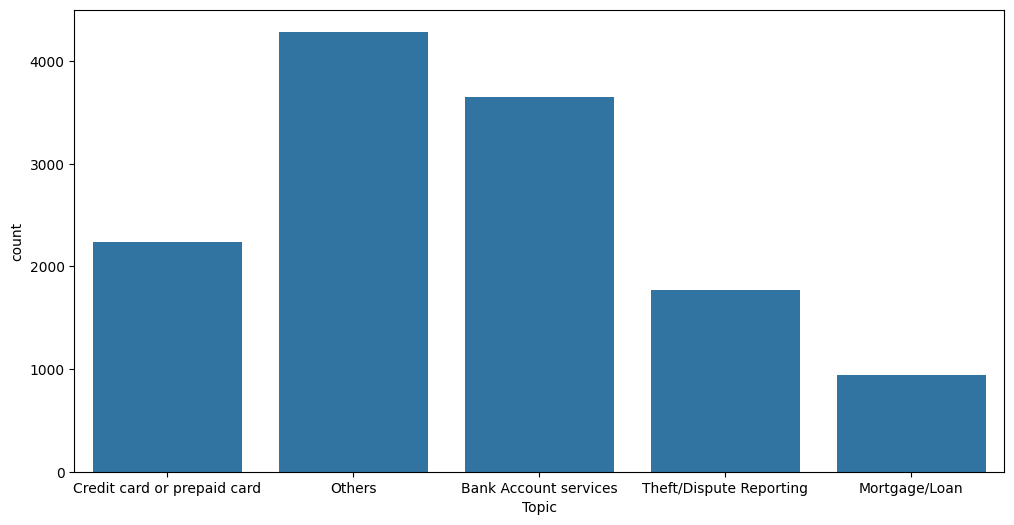

In [162]:
# Plot graph to check class imbalance
plt.figure(figsize=(12,6))
sns.countplot(x='Topic',data=df_clean)

In [163]:
#Keep the columns"complaint_what_happened" & "Topic" only in the new dataframe --> training_data

training_data = df_clean[['complaint_text','Topic']]

In [164]:
training_data.head()

,complaint_text,Topic
1,written notification about debt didnt receive enough information to verify debt good morning my name is xxxx xxxx and i appreciate it if you could help me put a stop to chase bank cardmember services \nin i wrote to chase asking for debt verification and what they sent me a statement which is not acceptable i am asking the bank to validate the debt instead i been receiving mail every month from them attempting to collect a debt \ni have a right to know this information as a consumer \n\nchase account xxxx xxxx xxxx xxxx thanks in advance for your help,Credit card or prepaid card
2,other features terms or problems problem with rewards from credit card i upgraded my xxxx xxxx card in and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account xxxx changed my anniversary date from xxxxxxxx to xxxxxxxx without my consent xxxx has the recording of the agent who was misled me,Others
10,incorrect information on your report information belongs to someone else chase card was reported on however fraudulent application have been submitted my identity without my consent to fraudulently obtain services do not extend credit without verifying the identity of the applicant,Credit card or prepaid card
11,incorrect information on your report information belongs to someone else on while trying to book a xxxx xxxx ticket i came across an offer for to be applied towards the ticket if i applied for a rewards card i put in my information for the offer and within less than a minute was notified via the screen that a decision could not be made i immediately contacted xxxx and was referred to chase bank i then immediately contacted chase bank within no more than of getting the notification on the screen and i was told by the chase representative i spoke with that my application was denied but she could not state why i asked for more information about the xxxx offer and she explained that even if i had been approved the credit offer only gets applied after the first account statement and could not be used to purchase the ticket i then explicitly told her i was glad i got denied and i was absolutely no longer interested in the account i asked that the application be withdrawn and the representative obliged this all happened no later than after putting in the application on notwithstanding my explicit request not to proceed with the application and contrary to what i was told by the chase representative chase did in fact go ahead to open a credit account in my name on this is now being reported in my credit report and chase has refused to correct this information on my credit report even though they went ahead to process an application which i did not consent to and out of their error,Credit card or prepaid card
14,managing an account funds not handled or disbursed as instructed my grand son give me check for i deposit it into my chase account after fund clear my chase bank closed my account never paid me my money they said they need to speek with my grand son check was clear money was taking by my chase bank refuse to pay me my money my grand son called chase times they told him i should call not him to verify the check owner he is out the country most the time date happen check number xxxx claim number is xxxx with chase,Bank Account services


In [165]:
## Reverse topic names mapping for supervised learning

reverse_topic_mapping = {
    'Bank Account services' :0,
    'Credit card or prepaid card':1,
    'Others':2,
    'Theft/Dispute Reporting':3,
    'Mortgage/Loan':4
}
#Replace Topics with Topic Names
training_data['Topic'] = training_data['Topic'].map(reverse_topic_mapping)
training_data.head()

,complaint_text,Topic
1,written notification about debt didnt receive enough information to verify debt good morning my name is xxxx xxxx and i appreciate it if you could help me put a stop to chase bank cardmember services \nin i wrote to chase asking for debt verification and what they sent me a statement which is not acceptable i am asking the bank to validate the debt instead i been receiving mail every month from them attempting to collect a debt \ni have a right to know this information as a consumer \n\nchase account xxxx xxxx xxxx xxxx thanks in advance for your help,1
2,other features terms or problems problem with rewards from credit card i upgraded my xxxx xxxx card in and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account xxxx changed my anniversary date from xxxxxxxx to xxxxxxxx without my consent xxxx has the recording of the agent who was misled me,2
10,incorrect information on your report information belongs to someone else chase card was reported on however fraudulent application have been submitted my identity without my consent to fraudulently obtain services do not extend credit without verifying the identity of the applicant,1
11,incorrect information on your report information belongs to someone else on while trying to book a xxxx xxxx ticket i came across an offer for to be applied towards the ticket if i applied for a rewards card i put in my information for the offer and within less than a minute was notified via the screen that a decision could not be made i immediately contacted xxxx and was referred to chase bank i then immediately contacted chase bank within no more than of getting the notification on the screen and i was told by the chase representative i spoke with that my application was denied but she could not state why i asked for more information about the xxxx offer and she explained that even if i had been approved the credit offer only gets applied after the first account statement and could not be used to purchase the ticket i then explicitly told her i was glad i got denied and i was absolutely no longer interested in the account i asked that the application be withdrawn and the representative obliged this all happened no later than after putting in the application on notwithstanding my explicit request not to proceed with the application and contrary to what i was told by the chase representative chase did in fact go ahead to open a credit account in my name on this is now being reported in my credit report and chase has refused to correct this information on my credit report even though they went ahead to process an application which i did not consent to and out of their error,1
14,managing an account funds not handled or disbursed as instructed my grand son give me check for i deposit it into my chase account after fund clear my chase bank closed my account never paid me my money they said they need to speek with my grand son check was clear money was taking by my chase bank refuse to pay me my money my grand son called chase times they told him i should call not him to verify the check owner he is out the country most the time date happen check number xxxx claim number is xxxx with chase,0


In [166]:
training_data[['complaint_text','Topic']][training_data.Topic==2].head(30)

,complaint_text,Topic
2,other features terms or problems problem with rewards from credit card i upgraded my xxxx xxxx card in and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account xxxx changed my anniversary date from xxxxxxxx to xxxxxxxx without my consent xxxx has the recording of the agent who was misled me,2
32,trouble using your card cant use card to make purchases my chase amazon card was declined for a catering order i had placed for my brothers funeral in the amount of i contacted chase around noon today and was asked the last numbers of my chase savings account and the other user on my account i responded that i did not have a savings and i am only authorized user customer rep told me they would call me back in minutes to keep the line open i didnt receive a call back after an hour so i contacted chase from the first call i thought someone was using my card fraudulently i spoke to the rep who transferred me to a supervisor xxxx who said the card was activated and the transaction would process called the catering company and card was declined i then used my xxxx xxxx card to pay for the order xxxx xxxx texted me asking if i was authorizing purchase and i responded yes contacted caterer and xxxx xxxx was declined i contacted chase again spoke to rep was told the initial questions are used to trick people to see what there answer would be she told me the cvv code was incorrectly being input by the caterer and i responded that i had gone over the numbers and cvv used was correct she told me the card was cleared for the purchase and she would monitor it for hours called caterer card declined use a mastercard which processed went to use chase amazon at restaurant at xxxx pm tonight in the amount of it was declined i was told by chase i was not over limit still frustrated figuring out multiple declines after several conversations with chase stating the card would be ok to use embarrassed as the caterer kept suggesting i was over my limit which i pay my card in full every month and chase confirmed that i was under my limit with the transaction never been declined by either chase or xxxx xxxx before today after multiple assurances that i was all set and card would be monitored to make sure transaction would clear it never did,2
40,problem with a lender or other company charging your account transaction was not authorized xxxx xxxx a sofa love seat table and chairs and was never delivered debit card charged bank says visa denied claim we have no furniture and no money,2
45,problem with a lender or other company charging your account transaction was not authorized i made a purchase with xxxx xxxx xxxx on in the amount of i was charged twice for this transaction i placed a disputes case with chase bank on when i noticed the charge on my account i called back on sunday about the provisional credit for the charge and again on monday i was told the charge had to post before a provisional credit could be provided i used my debt card on monday then tried to use it again but it would not work i went to chase bank on xxxx xxxx xxxx in xxxx xxxx nevada and was told that my account was closed due to fraudulent activity i was shocked because i had not reported fraud on my account i later found out that i was being accused by the disputes department of placing a fraudulent disputes case for the duplicate charge from xxxx xxxx xxxx i later contacted xxxx xxxx xxxx again and was told that they did see a duplicate charge and would credit my account within days i contacted the chase disputes department again on monday xxxxxxxx and explained thaxxxx xxxx xxxx xxxx would credit my account and that i did not like being accused of making a fraudulent disputes claim the escalation manager did not care and told me that chase decision on closing my account was final i had been a customer of chase for xxxx years my character has been ch

In [167]:
# x - y  split
X = training_data.complaint_text
y = training_data.Topic

In [168]:
#Write your code to get the Vector count

# Fit transform the X
count_vect = CountVectorizer()
X_vect = count_vect.fit_transform(X)

In [169]:
from sklearn.feature_extraction.text import TfidfTransformer
#Write your code here to transform the word vector to tf-idf
#Fit transform word vector to TF-IDF
tfidf_transformer = TfidfTransformer()
X_tfidf = tfidf_transformer.fit_transform(X_vect)

In [170]:
from sklearn.model_selection import train_test_split
# train test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.25, random_state=40, stratify=y)

In [171]:
# Write your code here to build any 3 models and evaluate them using the required metrics

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn import metrics
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_fscore_support

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [172]:
# utlity function to display the model report

def display_classification_report(model,metric):

    y_train_pred_proba = model.predict_proba(X_train)
    y_test_pred_proba = model.predict_proba(X_test)
    roc_auc_score_train = round(roc_auc_score(y_train, y_train_pred_proba,average='weighted',multi_class='ovr'),2)
    roc_auc_score_test = round(roc_auc_score(y_test, y_test_pred_proba,average='weighted',multi_class='ovr'),2)
    print("ROC AUC Score Train:", roc_auc_score_train)
    print("ROC AUC Score Test:", roc_auc_score_test)
    metric.append(roc_auc_score_train)
    metric.append(roc_auc_score_test)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    precision_train,recall_train,fscore_train,support_train=precision_recall_fscore_support(y_train,y_train_pred,average='weighted')
    precision_test,recall_test,fscore_test,support_test=precision_recall_fscore_support(y_test,y_test_pred,average='weighted')

    acc_score_train = round(accuracy_score(y_train,y_train_pred),2)
    acc_score_test = round(accuracy_score(y_test,y_test_pred),2)

    metric.append(acc_score_train)
    metric.append(acc_score_test)
    metric.append(round(precision_train,2))
    metric.append(round(precision_test,2))
    metric.append(round(recall_train,2))
    metric.append(round(recall_test,2))
    metric.append(round(fscore_train,2))
    metric.append(round(fscore_test,2))

    print('Train Accuracy :',acc_score_train)
    print('Test Accuracy :',acc_score_test)

    model_report_train = classification_report(y_train,y_train_pred)
    model_report_test = classification_report(y_test,y_test_pred)

    print('Classification Report for Train:\n',model_report_train)
    print('Classification Report for Test:\n',model_report_test)


    # Plot the confusion matrix
    fig, ax = plt.subplots(figsize=(12, 8))
    # Create the confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    cmp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
    cmp.plot(ax=ax)
    plt.xticks(rotation=80)

    plt.show();

In [173]:
# create 5 folds
folds = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 40)

In [174]:
# utility method to get the GridSearchCV object
def grid_search(model,folds,params,scoring):

    grid_search = GridSearchCV(model,
                                cv=folds,
                                param_grid=params,
                                scoring=scoring,
                                n_jobs=-1, verbose=1)
    return grid_search

In [175]:
# utility function to display the best score and parameters of the GridSearchCV model
def print_best_score_params(model):
    print("Best Score: ", model.best_score_)
    print("Best Hyperparameters: ", model.best_params_)

In [176]:
import sys
print(sys.version)


3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]


In [177]:
pip install tensorflow keras-tuner

In [178]:
import tensorflow as tf
print(tf.__version__)

2.20.0


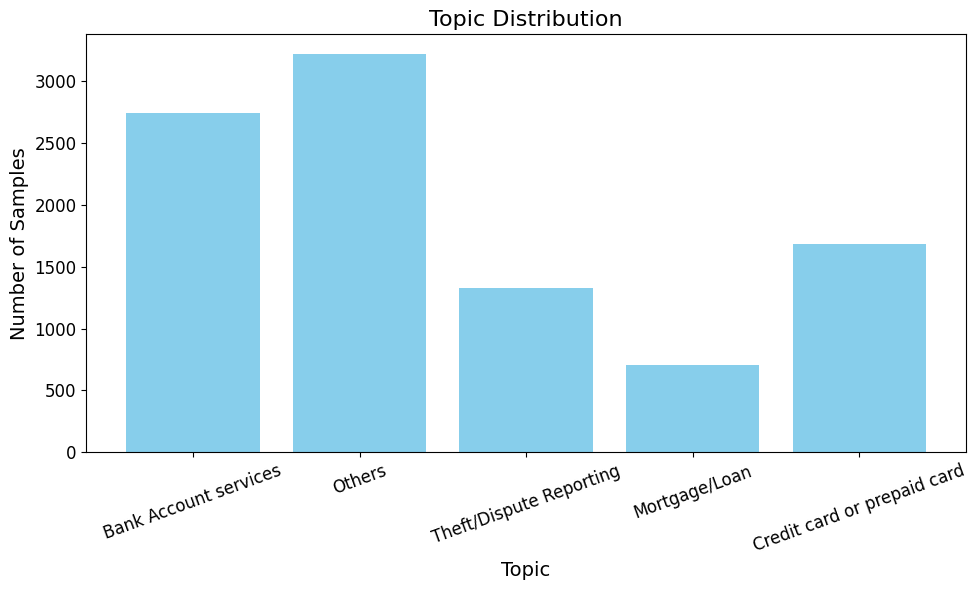

Number of tickets per topic:

Bank Account services: 2742 tickets
Credit card or prepaid card: 1682 tickets
Others: 3216 tickets
Theft/Dispute Reporting: 1328 tickets
Mortgage/Loan: 704 tickets


In [179]:
import matplotlib.pyplot as plt
from collections import Counter

# Provided reverse topic mapping
reverse_topic_mapping = {
    'Bank Account services' : 0,
    'Credit card or prepaid card': 1,
    'Others': 2,
    'Theft/Dispute Reporting': 3,
    'Mortgage/Loan': 4
}

# Assuming y_train is a 1D array or list of integer labels
# Example: y_train = [0, 1, 0, 3, 2, 4, 1, 1, 0, 3]

# Count how many times each class appears in y_train
label_counts = Counter(y_train)

# Map integer labels back to topic names
label_names = {v: k for k, v in reverse_topic_mapping.items()}
topics = [label_names[label] for label in label_counts.keys()]
counts = [label_counts[label] for label in label_counts.keys()]

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(topics, counts, color='skyblue')
plt.xlabel('Topic', fontsize=14)        # Increased font size
plt.ylabel('Number of Samples', fontsize=14)
plt.title('Topic Distribution', fontsize=16)
plt.xticks(rotation=20, fontsize=12)     # Font size for x-tick labels
plt.yticks(fontsize=12)                  # Font size for y-tick labels
plt.tight_layout()
plt.show()

from collections import Counter

# Your topic-to-label mapping
reverse_topic_mapping = {
    'Bank Account services': 0,
    'Credit card or prepaid card': 1,
    'Others': 2,
    'Theft/Dispute Reporting': 3,
    'Mortgage/Loan': 4
}

# Invert it to label-to-topic for easy lookup
label_to_topic = {v: k for k, v in reverse_topic_mapping.items()}

# Replace this with your actual y_train array or list
# Example:
# y_train = [0, 1, 0, 2, 3, 3, 4, 1, 1, 2]

# Count each label in y_train
label_counts = Counter(y_train)

# Print ticket counts per topic
print("Number of tickets per topic:\n")
for label, count in sorted(label_counts.items()):
    topic_name = label_to_topic.get(label, "Unknown")
    print(f"{topic_name}: {count} tickets")


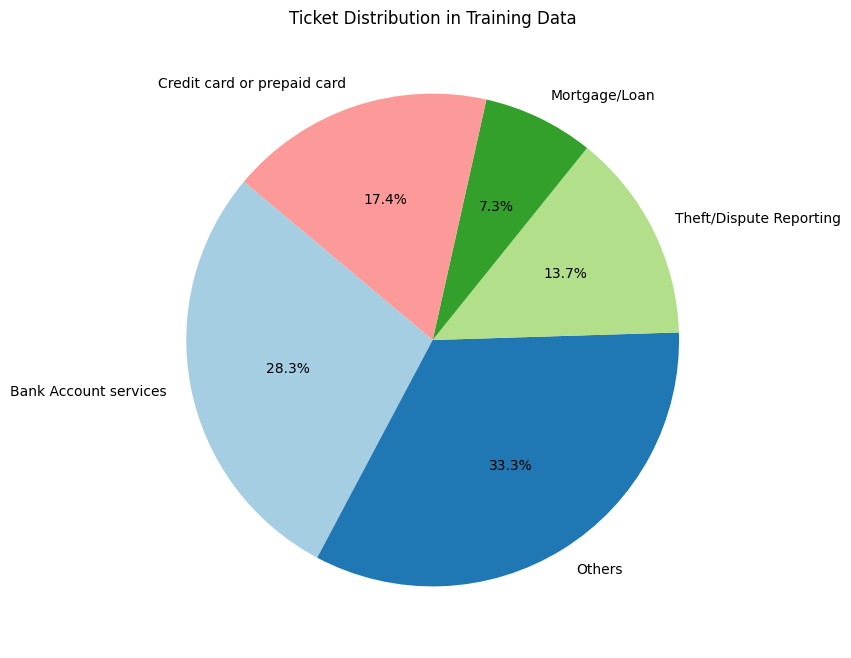

In [180]:
# Invert mapping for lookup
label_to_topic = {v: k for k, v in reverse_topic_mapping.items()}

# Count occurrences of each class in y_train
label_counts = Counter(y_train)

# Extract topics and corresponding counts
topics = [label_to_topic[label] for label in label_counts.keys()]
counts = [label_counts[label] for label in label_counts.keys()]

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=topics, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)

# Add a title
plt.title("Ticket Distribution in Training Data")

# Show plot
plt.show()

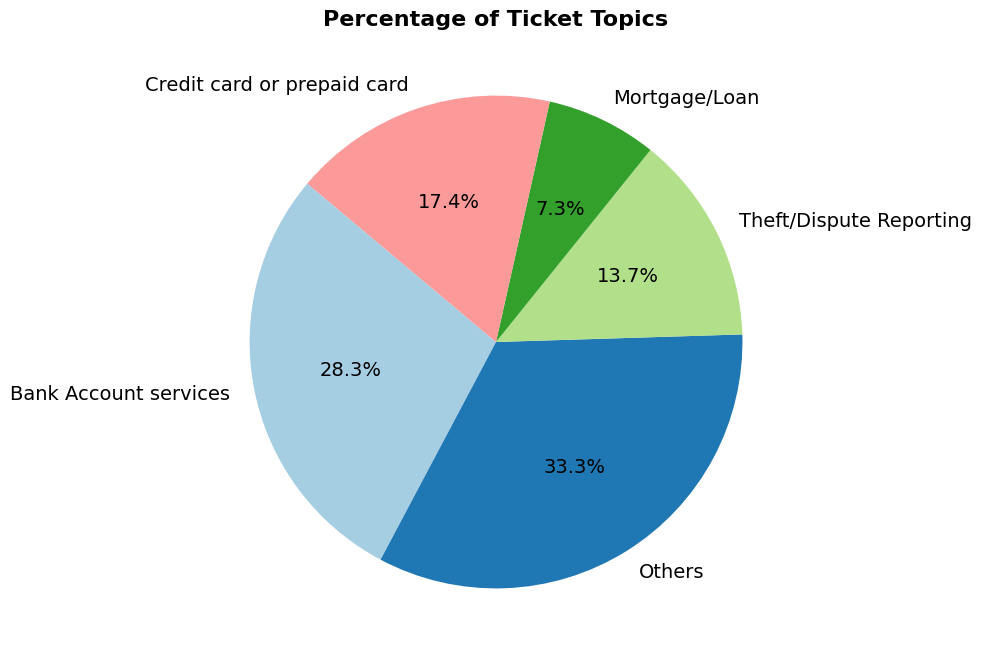

In [181]:
# Invert mapping for lookup
label_to_topic = {v: k for k, v in reverse_topic_mapping.items()}

# Count occurrences of each class in y_train
label_counts = Counter(y_train)

# Extract topics and corresponding counts
topics = [label_to_topic[label] for label in label_counts.keys()]
counts = [label_counts[label] for label in label_counts.keys()]

# Plot pie chart
plt.figure(figsize=(8, 8))  # Increase figure size
plt.pie(
    counts,
    labels=topics,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors,
    textprops={'fontsize': 14}  # Increase font size for labels and percentages
)

# Add a title with larger font
plt.title("Percentage of Ticket Topics", fontsize=16, fontweight='bold')

# Show plot
plt.show()

                      Topic  Number of Tickets  Percentage (%)
                     Others               3216           33.25
      Bank Account services               2742           28.35
Credit card or prepaid card               1682           17.39
    Theft/Dispute Reporting               1328           13.73
              Mortgage/Loan                704            7.28


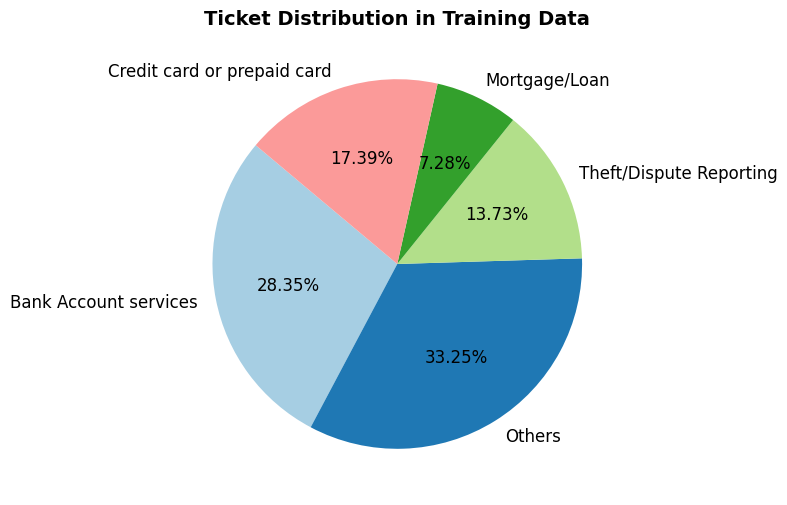

In [182]:
# Invert mapping for lookup
label_to_topic = {v: k for k, v in reverse_topic_mapping.items()}

# Count occurrences of each class in y_train
label_counts = Counter(y_train)

# Extract topics and corresponding counts
topics = [label_to_topic[label] for label in label_counts.keys()]
counts = [label_counts[label] for label in label_counts.keys()]

# Calculate percentages with 2 decimal places
total_samples = sum(counts)
percentages = [round((count / total_samples) * 100, 2) for count in counts]

# Create DataFrame for table display
df = pd.DataFrame({'Topic': topics, 'Number of Tickets': counts, 'Percentage (%)': percentages})
df = df.sort_values(by='Number of Tickets', ascending=False)  # Sort by count



# Display table
print(df.to_string(index=False))

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=topics,
    autopct=lambda p: '{:.2f}%'.format(p),  # Format percentages to 2 decimal places
    startangle=140,
    colors=plt.cm.Paired.colors,
    textprops={'fontsize': 12}
)

# Add a title
plt.title("Ticket Distribution in Training Data", fontsize=14, fontweight='bold')

# Show plot
plt.show()

In [183]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

# Utility function to display the model report
def display_classification_report(model, X_train, X_test, y_train, y_test, metric):
    # Predict probabilities for train and test sets
    y_train_pred_proba = model.predict(X_train)
    y_test_pred_proba = model.predict(X_test)
    #percent = 4

    # Calculate ROC AUC scores
    roc_auc_score_train = round(roc_auc_score(y_train, y_train_pred_proba, average='weighted', multi_class='ovr'), 4)
    roc_auc_score_test = round(roc_auc_score(y_test, y_test_pred_proba, average='weighted', multi_class='ovr'), 4)
    print("ROC AUC Score Train:", roc_auc_score_train)
    print("ROC AUC Score Test:", roc_auc_score_test)
    metric.append(roc_auc_score_train)
    metric.append(roc_auc_score_test)

    # Predict classes for train and test sets
    y_train_pred = np.argmax(y_train_pred_proba, axis=1)
    y_test_pred = np.argmax(y_test_pred_proba, axis=1)

    # Calculate precision, recall, F1-score, and support
    precision_train, recall_train, fscore_train, support_train = precision_recall_fscore_support(y_train, y_train_pred, average='weighted')
    precision_test, recall_test, fscore_test, support_test = precision_recall_fscore_support(y_test, y_test_pred, average='weighted')

    # Calculate accuracy
    acc_score_train = round(accuracy_score(y_train, y_train_pred), 4)
    acc_score_test = round(accuracy_score(y_test, y_test_pred), 4)

    # Append metrics to the list
    metric.append(acc_score_train)
    metric.append(acc_score_test)
    metric.append(round(precision_train, 4))
    metric.append(round(precision_test, 4))
    metric.append(round(recall_train, 4))
    metric.append(round(recall_test, 4))
    metric.append(round(fscore_train, 4))
    metric.append(round(fscore_test, 4))

    # Print accuracy
    print('Train Accuracy:', acc_score_train)
    print('Test Accuracy:', acc_score_test)
    print('Train Precision:', round(precision_train, 4))
    print('Test Precision:', round(precision_test, 4))
    print('Train Recall:', round(recall_train,4))
    print('Test Recall:', round(recall_test,4))
    print('Train F1 score:', round(fscore_train,4))
    print('Test F1 score:', round(fscore_test,4))


    # Print classification reports
    model_report_train = classification_report(y_train, y_train_pred)
    model_report_test = classification_report(y_test, y_test_pred)
    print('Classification Report for Train:\n', model_report_train)
    print('Classification Report for Test:\n', model_report_test)


    # Plot the confusion matrix
    fig, ax = plt.subplots(figsize=(12, 8))
    cm = confusion_matrix(y_test, y_test_pred)
    cmp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_train))
    cmp.plot(ax=ax)
    plt.xticks(rotation=80)
    plt.show()

def train_and_evaluate_model(model, X_train, X_test, y_train, y_test, model_name, batch_size=None, epochs=None):
    start_time = time.time()
    # Set default values only if not provided
    batch_size = batch_size or 64
    epochs = epochs or 20

    print(f"\n🚀 Training and evaluating **{model_name}** model...")
    print(f"🔧 Epochs: {epochs}, Batch size: {batch_size}\n")

    # Train the model
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        verbose=1
    )

    end_time = time.time()
    training_time_seconds = end_time - start_time  # Total time in seconds
    training_time_minutes = training_time_seconds / 60  # Convert to minutes

    # Convert to minutes and seconds for display
    minutes = int(training_time_minutes)
    seconds = int(training_time_seconds % 60)

    # Evaluate model performance
    metric = []
    display_classification_report(model, X_train, X_test, y_train, y_test, metric)

    # Add training time to metrics (using consistent variable names)
    metric.extend([
        training_time_seconds,  # Total time in seconds
        training_time_minutes   # Total time in minutes
    ])

    # Print training time information
    print(f"\n⏱️ Training time: {minutes} minutes {seconds} seconds ({training_time_seconds:.2f} seconds)")
    print(f"\n📊 Collected Metrics for {model_name}: {metric}")

    return {
        'metrics': metric,
        'history': history,
        'training_time_seconds': training_time_seconds,
        'training_time_minutes': training_time_minutes
    }

In [184]:
!pip install scikeras

In [185]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (9672, 24497)
y_train shape: (9672,)


In [186]:
from sklearn.decomposition import TruncatedSVD
import numpy as np

# Set number of components for dimensionality reduction
n_components = 500  # Adjust based on memory and model performance

# Apply TruncatedSVD
svd = TruncatedSVD(n_components=n_components, random_state=42)

# Transform the data (sparse to dense + reduction)
X_train_reduced = svd.fit_transform(X_train).astype(np.float32)
X_test_reduced = svd.transform(X_test).astype(np.float32)

# Reshape for RNN: (samples, timesteps=1, features)
X_train = X_train_reduced.reshape((X_train_reduced.shape[0], 1, X_train_reduced.shape[1]))
X_test = X_test_reduced.reshape((X_test_reduced.shape[0], 1, X_test_reduced.shape[1]))

# Confirm shapes
print("✅ Final X_train shape:", X_train.shape)
print("✅ Final X_test shape:", X_test.shape)

✅ Final X_train shape: (9672, 1, 500)
✅ Final X_test shape: (3224, 1, 500)



🚀 Training and evaluating **LSTM** model...
🔧 Epochs: 20, Batch size: 64

Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4113 - loss: 1.4340 - val_accuracy: 0.5679 - val_loss: 1.2241
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7484 - loss: 0.9280 - val_accuracy: 0.8614 - val_loss: 0.6357
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8972 - loss: 0.4535 - val_accuracy: 0.9023 - val_loss: 0.3602
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9262 - loss: 0.2807 - val_accuracy: 0.9156 - val_loss: 0.2723
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9438 - loss: 0.2101 - val_accuracy: 0.9178 - val_loss: 0.2328
Epoch 6/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9496 - loss: 0.1740 - val_accuracy: 0.9200 - val_loss: 0.2128
Epoch 7/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9574 - loss: 0.1497 - val_accuracy: 0.9237 - val_loss: 0.2003
Epoch 8/20
152/152 ━━━━━━━━━━

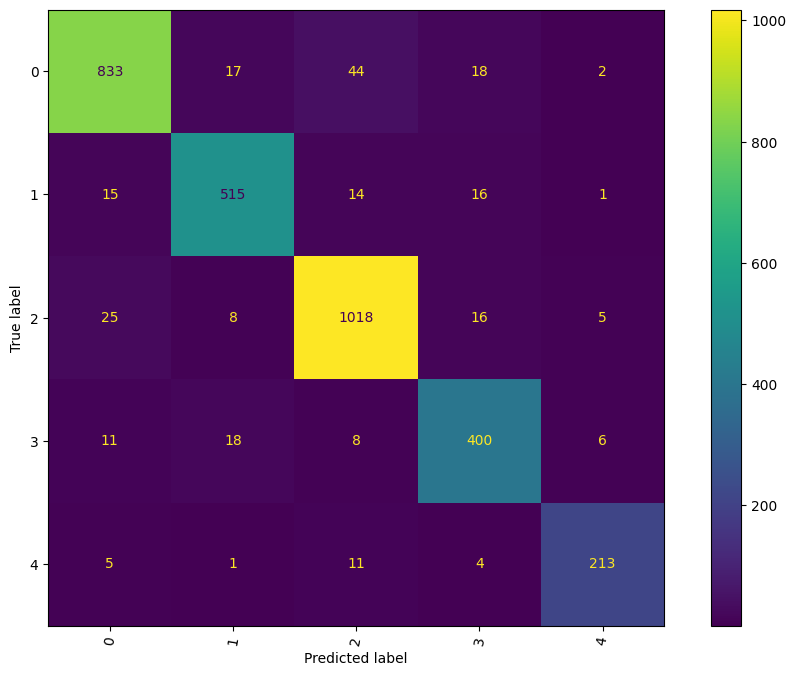


⏱️ Training time: 0 minutes 19 seconds (19.84 seconds)

📊 Collected Metrics for LSTM: [np.float64(0.9998), np.float64(0.9941), 0.9911, 0.924, np.float64(0.9911), np.float64(0.9242), np.float64(0.9911), np.float64(0.924), np.float64(0.9911), np.float64(0.924), 19.83903408050537, 0.33065056800842285]


In [187]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define LSTM model
def build_lstm_model():
    model = Sequential()
    model.add(LSTM(units=128, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.3))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))  # For multi-class classification
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Build and train LSTM model
lstm_model = build_lstm_model()
lstm_metrics = train_and_evaluate_model(lstm_model, X_train, X_test, y_train, y_test, model_name="LSTM")

# Metrics will be printed and plotted automatically from the utility functions
#print("✅ LSTM Metrics:", lstm_metrics)



🚀 Training and evaluating **GRU** model...
🔧 Epochs: 20, Batch size: 64

Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4914 - loss: 1.3433 - val_accuracy: 0.6849 - val_loss: 1.0539
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8266 - loss: 0.7259 - val_accuracy: 0.8809 - val_loss: 0.4825
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9105 - loss: 0.3572 - val_accuracy: 0.9085 - val_loss: 0.3079
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9334 - loss: 0.2423 - val_accuracy: 0.9181 - val_loss: 0.2484
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9484 - loss: 0.1907 - val_accuracy: 0.9172 - val_loss: 0.2217
Epoch 6/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9539 - loss: 0.1634 - val_accuracy: 0.9212 - val_loss: 0.2047
Epoch 7/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9605 - loss: 0.1403 - val_accuracy: 0.9256 - val_loss: 0.1945
Epoch 8/20
152/152 ━━━━━━━━━━━

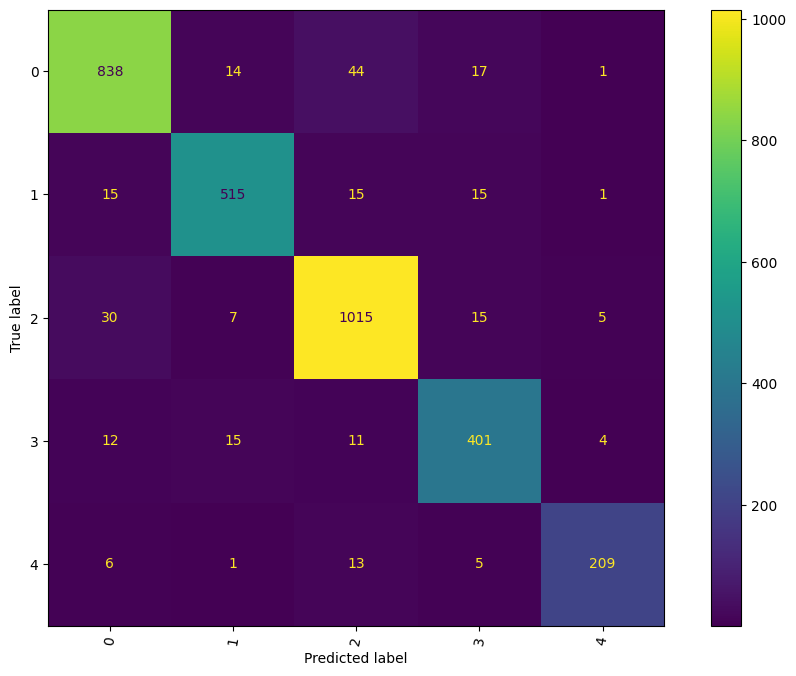


⏱️ Training time: 0 minutes 17 seconds (17.93 seconds)

📊 Collected Metrics for GRU: [np.float64(0.9998), np.float64(0.994), 0.9912, 0.9237, np.float64(0.9912), np.float64(0.924), np.float64(0.9912), np.float64(0.9237), np.float64(0.9912), np.float64(0.9237), 17.92530846595764, 0.298755141099294]


In [188]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

# Define GRU model
def build_gru_model():
    model = Sequential()
    model.add(GRU(units=128, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.3))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))  # For multi-class classification
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Build and train GRU model
gru_model = build_gru_model()
gru_metrics = train_and_evaluate_model(gru_model, X_train, X_test, y_train, y_test, model_name="GRU")

In [189]:
# Install the compatible scikit-learn version
!pip install scikit-learn==1.5.2

In [190]:
import sklearn
import keras
import scikeras
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

In [191]:
print("TensorFlow", tf.__version__)
print("scikit-learn:", sklearn.__version__)
print("SciKeras:", scikeras.__version__)
print("Keras:", keras.__version__)

TensorFlow 2.20.0
scikit-learn: 1.5.2
SciKeras: 0.13.0
Keras: 3.13.2


Fitting 3 folds for each of 24 candidates, totalling 72 fits

✅ Best Hyperparameters for LSTM:
{'batch_size': 32, 'dropout_rate': 0.5, 'epochs': 10, 'learning_rate': 0.001, 'optimizer': 'rmsprop'}

🚀 Training and evaluating **LSTM (Tuned)** model...
🔧 Epochs: 10, Batch size: 32

Epoch 1/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9711 - loss: 0.0860 - val_accuracy: 0.9237 - val_loss: 0.1867
Epoch 2/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9752 - loss: 0.0812 - val_accuracy: 0.9243 - val_loss: 0.1910
Epoch 3/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9739 - loss: 0.0787 - val_accuracy: 0.9243 - val_loss: 0.1932
Epoch 4/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9757 - loss: 0.0734 - val_accuracy: 0.9237 - val_loss: 0.1962
Epoch 5/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9772 - loss: 0.0713 - val_accuracy: 0.9234 - val_loss: 0.1981
Epoch 6/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9769 - loss: 0

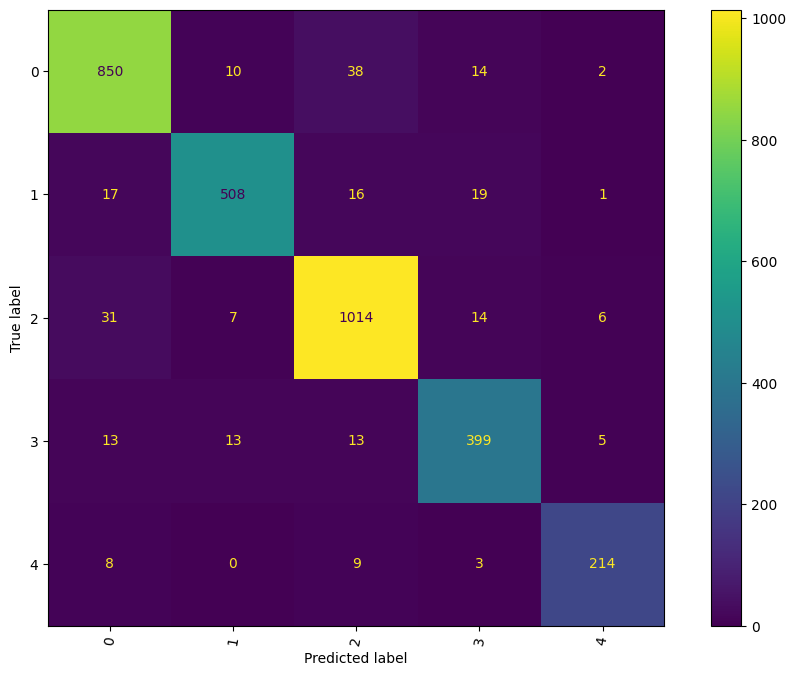


⏱️ Training time: 0 minutes 16 seconds (16.41 seconds)

📊 Collected Metrics for LSTM (Tuned): [np.float64(0.9999), np.float64(0.994), 0.9926, 0.9259, np.float64(0.9926), np.float64(0.9261), np.float64(0.9926), np.float64(0.9259), np.float64(0.9926), np.float64(0.9259), 16.40973138809204, 0.27349552313486736]


In [192]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

# ----------------------------
# 🔧 Function to build LSTM model with tunable hyperparameters
# ----------------------------
def build_lstm_model(optimizer='adam', dropout_rate=0.3, learning_rate=0.001):
    model = Sequential()
    model.add(LSTM(units=128, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))

    # Select optimizer
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError("Unsupported optimizer")

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ----------------------------
# ⚙️ Wrap the model with KerasClassifier
# ----------------------------
lstm_clf = KerasClassifier(
    model=build_lstm_model,
    optimizer='adam',        # default values (will be tuned)
    dropout_rate=0.3,
    learning_rate=0.001,
    batch_size=64,
    epochs=10,
    verbose=0
)

# ----------------------------
# 🔍 Define hyperparameter grid
# ----------------------------
param_grid = {
    'optimizer': ['adam', 'rmsprop'],
    'dropout_rate': [0.2, 0.3, 0.5],
    'learning_rate': [0.001, 0.0005],
    'batch_size': [32, 64],
    'epochs': [10]  # You can increase this if needed
}

# ----------------------------
# 🧠 Run Grid Search
# ----------------------------
grid = GridSearchCV(estimator=lstm_clf, param_grid=param_grid, cv=3, verbose=1)
grid_result = grid.fit(X_train, y_train)

# ----------------------------
# ✅ Best hyperparameters
# ----------------------------
best_params = grid_result.best_params_
print("\n✅ Best Hyperparameters for LSTM:")
print(best_params)

# ----------------------------
# 📊 Evaluate the best model using your functions
# ----------------------------
best_lstm_model = grid_result.best_estimator_.model_
lstm_tuned_metrics = train_and_evaluate_model(
    best_lstm_model,
    X_train, X_test, y_train, y_test,
    model_name="LSTM (Tuned)",
    batch_size=best_params['batch_size'],
    epochs=best_params['epochs']
)


Fitting 3 folds for each of 24 candidates, totalling 72 fits

✅ Best Hyperparameters for GRU:
{'batch_size': 32, 'dropout_rate': 0.5, 'epochs': 10, 'learning_rate': 0.001, 'optimizer': 'adam'}

🚀 Training and evaluating **GRU (Tuned)** model...
🔧 Epochs: 10, Batch size: 32

Epoch 1/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9695 - loss: 0.0884 - val_accuracy: 0.9221 - val_loss: 0.1868
Epoch 2/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9728 - loss: 0.0848 - val_accuracy: 0.9234 - val_loss: 0.1877
Epoch 3/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9734 - loss: 0.0804 - val_accuracy: 0.9240 - val_loss: 0.1923
Epoch 4/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9746 - loss: 0.0788 - val_accuracy: 0.9234 - val_loss: 0.1941
Epoch 5/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9752 - loss: 0.0758 - val_accuracy: 0.9231 - val_loss: 0.1998
Epoch 6/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9757 - loss: 0.0732

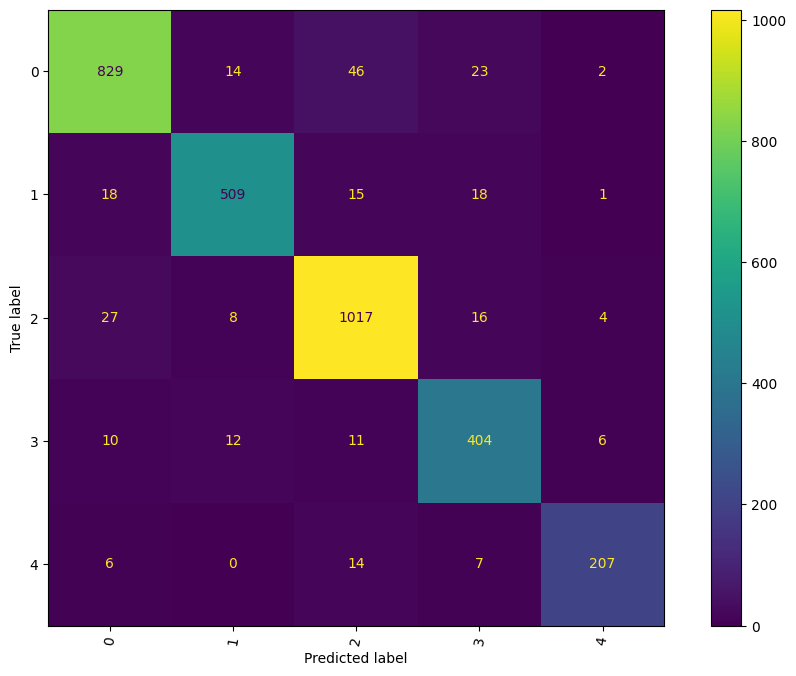


⏱️ Training time: 0 minutes 16 seconds (16.02 seconds)

📊 Collected Metrics for GRU (Tuned): [np.float64(0.9999), np.float64(0.9939), 0.9903, 0.92, np.float64(0.9903), np.float64(0.9207), np.float64(0.9903), np.float64(0.92), np.float64(0.9903), np.float64(0.92), 16.01716685295105, 0.2669527808825175]


In [193]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

# ----------------------------
# 🔧 Function to build GRU model with tunable hyperparameters
# ----------------------------
def build_gru_model(optimizer='adam', dropout_rate=0.3, learning_rate=0.001):
    model = Sequential()
    model.add(GRU(units=128, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))

    # Select optimizer
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError("Unsupported optimizer")

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ----------------------------
# ⚙️ Wrap the model with KerasClassifier
# ----------------------------
gru_clf = KerasClassifier(
    model=build_gru_model,
    optimizer='adam',        # default values (will be tuned)
    dropout_rate=0.3,
    learning_rate=0.001,
    batch_size=64,
    epochs=10,
    verbose=0
)

# ----------------------------
# 🔍 Define hyperparameter grid
# ----------------------------
param_grid = {
    'optimizer': ['adam', 'rmsprop'],
    'dropout_rate': [0.2, 0.3, 0.5],
    'learning_rate': [0.001, 0.0005],
    'batch_size': [32, 64],
    'epochs': [10]  # You can increase this if needed
}

# ----------------------------
# 🧠 Run Grid Search
# ----------------------------
grid = GridSearchCV(estimator=gru_clf, param_grid=param_grid, cv=3, verbose=1)
grid_result = grid.fit(X_train, y_train)

# ----------------------------
# ✅ Best hyperparameters
# ----------------------------
best_params = grid_result.best_params_
print("\n✅ Best Hyperparameters for GRU:")
print(best_params)

# ----------------------------
# 📊 Evaluate the best model using your functions
# ----------------------------
best_gru_model = grid_result.best_estimator_.model_
gru_tuned_metrics = train_and_evaluate_model(
    best_gru_model,
    X_train, X_test, y_train, y_test,
    model_name="GRU (Tuned)",
    batch_size=best_params['batch_size'],
    epochs=best_params['epochs']
)



🚀 Training and evaluating **SRN** model...
🔧 Epochs: 20, Batch size: 64

Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.5563 - loss: 1.2475 - val_accuracy: 0.7612 - val_loss: 0.9002
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8591 - loss: 0.6209 - val_accuracy: 0.8905 - val_loss: 0.4439
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9189 - loss: 0.3415 - val_accuracy: 0.9135 - val_loss: 0.3077
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9327 - loss: 0.2450 - val_accuracy: 0.9144 - val_loss: 0.2549
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9467 - loss: 0.1971 - val_accuracy: 0.9166 - val_loss: 0.2282
Epoch 6/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9548 - loss: 0.1679 - val_accuracy: 0.9203 - val_loss: 0.2127
Epoch 7/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9576 - loss: 0.1488 - val_accuracy: 0.9212 - val_loss: 0.2017
Epoch 8/20
152/152 ━━━━━━━━━━

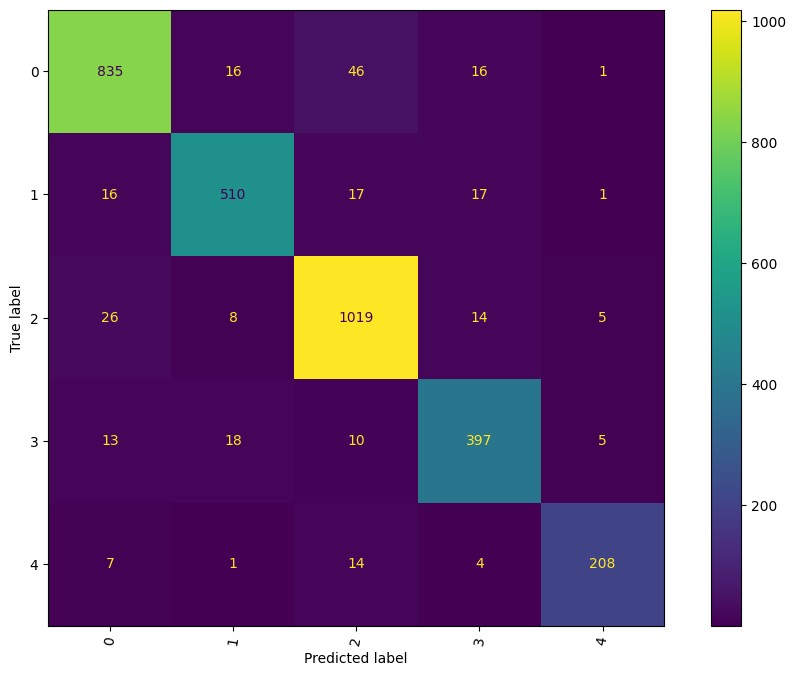


⏱️ Training time: 0 minutes 16 seconds (16.43 seconds)

📊 Collected Metrics for SRN: [np.float64(0.9998), np.float64(0.994), 0.9897, 0.9209, np.float64(0.9897), np.float64(0.9211), np.float64(0.9897), np.float64(0.9209), np.float64(0.9897), np.float64(0.9208), 16.43314266204834, 0.273885711034139]


In [194]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

def build_srn_model():
    model = Sequential()
    model.add(SimpleRNN(units=128, input_shape=(X_train.shape[1], X_train.shape[2])))  # (timesteps, features)
    model.add(Dropout(0.3))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Train and evaluate SRN model
srn_model = build_srn_model()
srn_metrics = train_and_evaluate_model(srn_model, X_train, X_test, y_train, y_test, model_name="SRN")


In [195]:
import pandas as pd

# Define metric names
metric_names = [
    'ROC_AUC Score(Train)',
    'ROC_AUC Score(Test)',
    'Accuracy(Train)',
    'Accuracy(Test)',
    'Precision(Train)',
    'Precision(Test)',
    'Recall(Train)',
    'Recall(Test)',
    'F1-Score(Train)',
    'F1-Score(Test)'
]

# Create final comparison table
final_metric = pd.DataFrame({
    'Metric': metric_names,
    'LSTM': lstm_metrics['metrics'][:10],
    'LSTM (Tuned Hyperparameters)': lstm_tuned_metrics['metrics'][:10],
    'GRU': gru_metrics['metrics'][:10],
    'GRU (Tuned Hyperparameters)': gru_tuned_metrics['metrics'][:10],
    'SRN': srn_metrics['metrics'][:10]
})

# Function for alternating row colours
def highlight_rows(row):
    return [
        'background-color: lightgrey'
        if row.name % 2 == 1
        else 'background-color: white'
        for _ in row
    ]

# Display with 4 decimal places
styled_final_metric = (
    final_metric.style
    .apply(highlight_rows, axis=1)
    .format(precision=4)
)

styled_final_metric

,Metric,LSTM,LSTM (Tuned Hyperparameters),GRU,GRU (Tuned Hyperparameters),SRN
0,ROC_AUC Score(Train),0.9998,0.9999,0.9998,0.9999,0.9998
1,ROC_AUC Score(Test),0.9941,0.9940,0.9940,0.9939,0.9940
2,Accuracy(Train),0.9911,0.9926,0.9912,0.9903,0.9897
3,Accuracy(Test),0.9240,0.9259,0.9237,0.9200,0.9209
4,Precision(Train),0.9911,0.9926,0.9912,0.9903,0.9897
5,Precision(Test),0.9242,0.9261,0.9240,0.9207,0.9211
6,Recall(Train),0.9911,0.9926,0.9912,0.9903,0.9897
7,Recall(Test),0.9240,0.9259,0.9237,0.9200,0.9209
8,F1-Score(Train),0.9911,0.9926,0.9912,0.9903,0.9897
9,F1-Score(Test),0.9240,0.9259,0.9237,0.9200,0.9208
